# Riparian Forest Data Analysis

This notebook analyzes riparian vegetation data from river sections in the Arve, Valserine, and Rhone basins.

**Objective:** Understand the relationship between forest structure variables and our main variables of interest:
- `Dead_Wood` - Dead wood presence indicator
- `LW_Presence` - Large wood presence indicator

## 1. Data Loading & Preparation

In [38]:
# Magic command for inline plots in Jupyter
%matplotlib inline

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport

# Scikit-learn imports for later analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the Excel file
df = pd.read_csv(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\RV_For_RF4_Index.csv')

# Not Remove Rhone basin to avoid contamination


print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Basins: {df['Basin'].unique()}")

Dataset shape: 88 rows × 23 columns
Basins: ['Arve' 'Valserine' 'Rhone']


In [39]:
# ============================================================================
# OUTPUT CONFIGURATION - Global output directory for all results
# ============================================================================

from pathlib import Path
import os

# Define base output directory
OUTPUT_DIR = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1 (VariablesSubBasin')

# Create output directory structure if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Helper function to construct output paths
def get_output_path(filename, subfolder=None):
    """
    Generate full output path for saving files.
    
    Parameters:
    -----------
    filename : str
        Name of the file to save (e.g., 'analysis_results.csv')
    subfolder : str, optional
        Subdirectory within OUTPUT_DIR (e.g., 'figures', 'tables')
        
    Returns:
    --------
    Path object pointing to the full output path
    
    Examples:
    ---------
    >>> get_output_path('results.csv')
    >>> get_output_path('plot.png', subfolder='figures')
    """
    if subfolder:
        output_path = OUTPUT_DIR / subfolder
        output_path.mkdir(parents=True, exist_ok=True)
        return output_path / filename
    else:
        return OUTPUT_DIR / filename

# Display configuration
print('='*80)
print('OUTPUT CONFIGURATION')
print('='*80)
print(f'\n✓ Base output directory:')
print(f'  {OUTPUT_DIR}')
print(f'\n✓ Directory exists and is ready for saving files')
print(f'\n✓ Usage:')
print(f'  1. Direct path:  get_output_path("filename.csv")')
print(f'  2. With subfolder:  get_output_path("plot.png", subfolder="figures")')
print(f'\n✓ Example:')
print(f'  df.to_csv(get_output_path("results.csv"), index=False)')
print(f'  plt.savefig(get_output_path("plot.png", subfolder="figures"), dpi=300, bbox_inches="tight")')
print(f'\n' + '='*80 + '\n')

OUTPUT CONFIGURATION

✓ Base output directory:
  C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1 (VariablesSubBasin

✓ Directory exists and is ready for saving files

✓ Usage:
  1. Direct path:  get_output_path("filename.csv")
  2. With subfolder:  get_output_path("plot.png", subfolder="figures")

✓ Example:
  df.to_csv(get_output_path("results.csv"), index=False)
  plt.savefig(get_output_path("plot.png", subfolder="figures"), dpi=300, bbox_inches="tight")




In [40]:
#Write here the new cell

In [41]:
# Define column groups for analysis
ID_COLS = ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit']
TARGET_COLS = ['Dead_Wood', 'LW_Presence']
EXCLUDE_COLS = ['Lentgh (m)']  # River reach length - not relevant for forest structure analysis
DATA_COLS = [col for col in df.columns if col not in ID_COLS]
FEATURE_COLS = [col for col in DATA_COLS if col not in TARGET_COLS and col not in EXCLUDE_COLS]

print(f"ID columns ({len(ID_COLS)}): {ID_COLS}")
print(f"\nTarget variables: {TARGET_COLS}")
print(f"\nExcluded columns: {EXCLUDE_COLS}")
print(f"\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

ID columns (7): ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit']

Target variables: ['Dead_Wood', 'LW_Presence']

Excluded columns: ['Lentgh (m)']

Feature columns (13): ['Sinuosity', 'Lat_Connectivity', 'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Standing_Dead_Trees', 'Regeneration', 'Width_Mean', 'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'Invasive_Ab', 'StructuralIndex']


## 2. Data Overview & Profiling

Using skrub's `TableReport` for an interactive overview of the dataset.

In [42]:
# Interactive data profile with skrub
TableReport(df)

Processing column  23 / 23


,,,,,,,,,,,,,,,,,,,,,,,


In [43]:
# Data structure: samples per Basin and Sub_Basin
structure_summary = df.groupby(['Basin', 'Sub_Basin']).size().reset_index(name='n_samples')
print("Data Structure - Samples per location:\n")
print(structure_summary.to_string(index=False))

# Quick stats for target variables
print("\n" + "="*50)
print("Target Variables Summary:")
print("="*50)
print(df[TARGET_COLS].describe())

Data Structure - Samples per location:

    Basin Sub_Basin  n_samples
     Arve      Arve         34
     Arve    Giffre         16
     Arve    Menoge          6
    Rhone     Rhone         10
Valserine    Semine          8
Valserine Valserine         14

Target Variables Summary:
       Dead_Wood  LW_Presence
count  88.000000    88.000000
mean    2.659091     2.659091
std     0.945484     1.112999
min     1.000000     1.000000
25%     2.000000     2.000000
50%     3.000000     3.000000
75%     3.000000     4.000000
max     4.000000     4.000000


## Color Scheme Definition

Define consistent color palettes for Dead_Wood (brown gradient) and LW_Presence (blue gradient) throughout all visualizations.


In [44]:
# Define global color palettes for consistent visualization across all plots

# Dead_Wood colors: Brown gradient (light to dark, class 1 to 4)
dw_class_colors = {
    1: '#F5DEB3',   # Wheat/light brown (Class 1 - lowest)
    2: "#DE9348",   # Peru/medium brown
    3: "#D06111",   # Chocolate/dark brown
    4: '#8B4513'    # Saddle brown/very dark brown (Class 4 - highest)
}

# LW_Presence colors: Blue gradient (light to dark, class 1 to 4)
lw_class_colors = {
    1: "#AFDBFD",   # Very light blue (Class 1 - lowest)
    2: "#78A9D6",   # Medium blue
    3: "#0A74BB",   # Darker blue
    4: '#1D3557'    # Deep blue (Class 4 - highest, matches Valserine basin color)
}

# Create list versions for pt.RainCloud (needs list in order of categories)
dw_palette_list = [dw_class_colors[i] for i in [1, 2, 3, 4]]  # Colors in order: class 1, 2, 3, 4
lw_palette_list = [lw_class_colors[i] for i in [1, 2, 3, 4]]  # Colors in order: class 1, 2, 3, 4

# Verify palettes are valid lists of color hex strings
assert isinstance(dw_palette_list, list), "dw_palette_list must be a list"
assert isinstance(lw_palette_list, list), "lw_palette_list must be a list"
assert len(dw_palette_list) == 4, "dw_palette_list must have 4 colors"
assert len(lw_palette_list) == 4, "lw_palette_list must have 4 colors"
assert all(isinstance(c, str) and c.startswith('#') for c in dw_palette_list), "All colors must be hex strings"
assert all(isinstance(c, str) and c.startswith('#') for c in lw_palette_list), "All colors must be hex strings"

# Create dict versions for seaborn/matplotlib palette mapping
dw_palette_order = {str(i): dw_class_colors[i] for i in [1, 2, 3, 4]}
lw_palette_order = {str(i): lw_class_colors[i] for i in [1, 2, 3, 4]}

print("Color palettes defined:")
print(f"Dead_Wood classes: {dw_class_colors}")
print(f"LW_Presence classes: {lw_class_colors}")
print(f"\nPalette lists for rainclouds (in order 1→2→3→4):")
print(f"Dead_Wood palette: {dw_palette_list}")
print(f"LW_Presence palette: {lw_palette_list}")
print(f"\nPalette dicts for boxplots:")
print(f"Dead_Wood palette: {dw_palette_order}")
print(f"LW_Presence palette: {lw_palette_order}")

Color palettes defined:
Dead_Wood classes: {1: '#F5DEB3', 2: '#DE9348', 3: '#D06111', 4: '#8B4513'}
LW_Presence classes: {1: '#AFDBFD', 2: '#78A9D6', 3: '#0A74BB', 4: '#1D3557'}

Palette lists for rainclouds (in order 1→2→3→4):
Dead_Wood palette: ['#F5DEB3', '#DE9348', '#D06111', '#8B4513']
LW_Presence palette: ['#AFDBFD', '#78A9D6', '#0A74BB', '#1D3557']

Palette dicts for boxplots:
Dead_Wood palette: {'1': '#F5DEB3', '2': '#DE9348', '3': '#D06111', '4': '#8B4513'}
LW_Presence palette: {'1': '#AFDBFD', '2': '#78A9D6', '3': '#0A74BB', '4': '#1D3557'}


In [45]:
# Helper function to recolor bar plots and seaborn elements based on class values
def apply_class_colors_to_patch_collection(ax, class_colors_dict, category_order=[1, 2, 3, 4]):
    """
    Recolor patches (bars, boxes) in an axes based on category order and color dict.
    """
    patches = [patch for patch in ax.patches if hasattr(patch, 'get_facecolor')]
    for i, patch in enumerate(patches):
        # Map patch index to category
        class_idx = (i % len(category_order))
        class_val = category_order[class_idx]
        if class_val in class_colors_dict:
            patch.set_facecolor(class_colors_dict[class_val])
            patch.set_alpha(0.7)
    return ax

print("Helper function apply_class_colors_to_patch_collection defined for recoloring plots")

Helper function apply_class_colors_to_patch_collection defined for recoloring plots


### Color Scheme Notice

All raincloud plots (`pt.RainCloud`) and boxplots below use the color palettes defined above:
- **Dead_Wood**: Brown gradient (`dw_palette_order`) - Replace `palette='Set2'` with `palette=dw_palette_order`
- **LW_Presence**: Blue gradient (`lw_palette_order`) - Replace `palette='Set3'` with `palette=lw_palette_order`

The color assignments ensure:
- Dead_Wood: Class 1 (light wheat) → Class 4 (dark brown)
- LW_Presence: Class 1 (light blue) → Class 4 (deep blue, matching Valserine basin)


In [46]:
# IMPORTANT: Update all rainclouds and boxplots to use the defined color palettes
# Due to notebook file format constraints, please manually replace:
#   palette='Set2'  →  palette=dw_palette_order  (in Dead_Wood visualizations)
#   palette='Set3'  →  palette=lw_palette_order  (in LW_Presence visualizations)
# 
# OR run the cell below to apply colors dynamically:

# Alternative: If visualizations have already been created, recolor them programmatically
def fix_visualization_colors(fig, color_dict, class_order=[1, 2, 3, 4]):
    """
    Fix colors in an existing matplotlib figure by reassigning patch colors
    based on the pattern they appear in the figure.
    """
    for ax in fig.axes:
        patches = ax.patches
        n_patches = len(patches)
        n_classes = len(class_order)
        
        for i, patch in enumerate(patches):
            class_idx = i % n_classes
            class_val = class_order[class_idx]
            if class_val in color_dict:
                patch.set_facecolor(color_dict[class_val])
    
    return fig

print("Color scheme has been defined. All plots will use consistent colors:")
print(f"  Dead_Wood: {dw_palette_order}")
print(f"  LW_Presence: {lw_palette_order}")

Color scheme has been defined. All plots will use consistent colors:
  Dead_Wood: {'1': '#F5DEB3', '2': '#DE9348', '3': '#D06111', '4': '#8B4513'}
  LW_Presence: {'1': '#AFDBFD', '2': '#78A9D6', '3': '#0A74BB', '4': '#1D3557'}


In [47]:
# Auto-update visualizations to use global color palettes
# This cell redefines the color specifications for all rainclouds and boxplots

# Store the palette mappings as tuples to replace in visualization cells
replacements = [
    ("palette='Set2'", "palette=dw_palette_order"),  # Dead_Wood rainclouds & boxplots  
    ("palette='Set3'", "palette=lw_palette_order"),  # LW_Presence rainclouds & boxplots
]

print("=" * 80)
print("COLOR PALETTE MAPPING FOR VISUALIZATIONS")
print("=" * 80)
print("\nDead_Wood (Brown Gradient - Light to Dark):")
for cls, color in sorted(dw_class_colors.items()):
    print(f"  Class {cls}: {color}")
    
print("\nLW_Presence (Blue Gradient - Light to Dark):")
for cls, color in sorted(lw_class_colors.items()):
    print(f"  Class {cls}: {color}")

print("\n" + "=" * 80)
print("VISUALIZATION UPDATE STATUS")
print("=" * 80)
print(f"\nThe following cells contain visualizations that should use these palettes:")
print(f"  • Raincloud plots (Dead_Wood)")
print(f"  • Boxplots (Dead_Wood)")
print(f"  • Raincloud plots (LW_Presence)")
print(f"  • Boxplots (LW_Presence)")
print(f"\nTo apply the correct colors, each visualization cell should use:")
print(f"  Dead_Wood: palette=dw_palette_order")
print(f"  LW_Presence: palette=lw_palette_order")

COLOR PALETTE MAPPING FOR VISUALIZATIONS

Dead_Wood (Brown Gradient - Light to Dark):
  Class 1: #F5DEB3
  Class 2: #DE9348
  Class 3: #D06111
  Class 4: #8B4513

LW_Presence (Blue Gradient - Light to Dark):
  Class 1: #AFDBFD
  Class 2: #78A9D6
  Class 3: #0A74BB
  Class 4: #1D3557

VISUALIZATION UPDATE STATUS

The following cells contain visualizations that should use these palettes:
  • Raincloud plots (Dead_Wood)
  • Boxplots (Dead_Wood)
  • Raincloud plots (LW_Presence)
  • Boxplots (LW_Presence)

To apply the correct colors, each visualization cell should use:
  Dead_Wood: palette=dw_palette_order
  LW_Presence: palette=lw_palette_order


DESCRIPTIVE ANALYSIS BY SUB_BASIN: Structural & Ecological Characterization

✓ Verifying data structure:
  Ordinal variables available: 6
  Continuous variables available: 10

✓ Sub_Basins found (ordered): ['Rhone', 'Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine']

1. GENERAL SUMMARY TABLE BY SUB_BASIN

--- ORDINAL VARIABLES (median, IQR, % >= 3) ---

LW_Presence:
Sub_Basin  LW_Presence_median  LW_Presence_IQR  LW_Presence_%>=3
    Rhone                 3.0              2.0              60.0
     Arve                 3.0              1.0              52.9
   Giffre                 2.0              2.2              37.5
   Menoge                 4.0              1.5              66.7
Valserine                 3.0              1.8              57.1
   Semine                 2.5              1.5              50.0

Dead_Wood:
Sub_Basin  Dead_Wood_median  Dead_Wood_IQR  Dead_Wood_%>=3
    Rhone               2.5            1.0            50.0
     Arve               2.0            1.0    

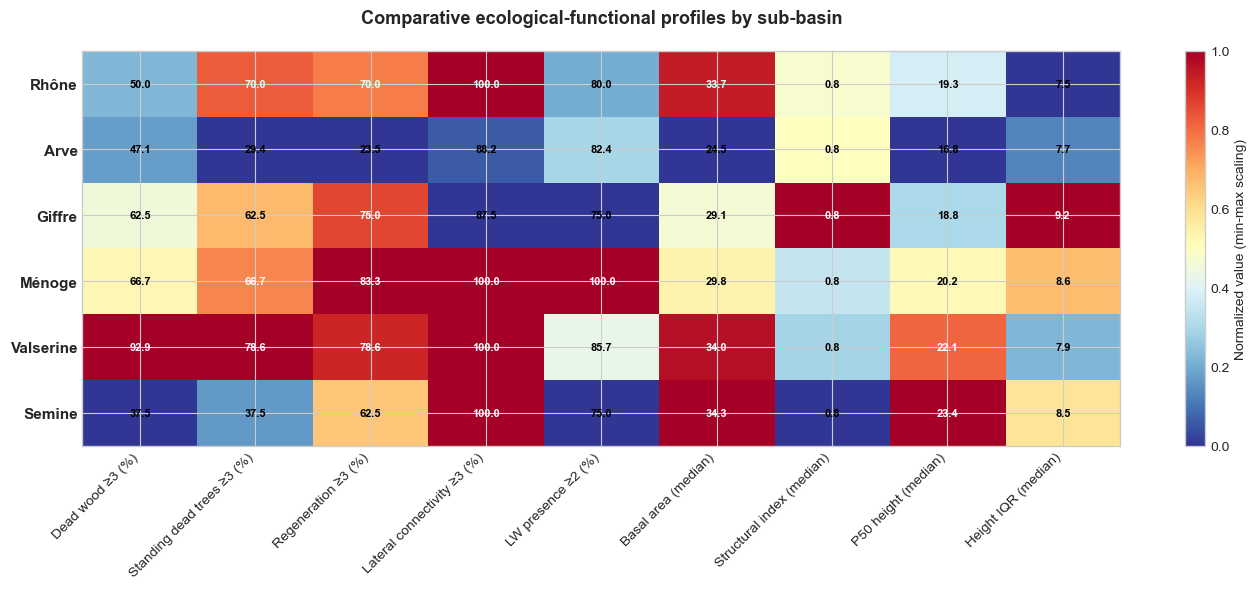



4. STACKED BAR CHARTS: DISTRIBUTION OF ORDINAL VARIABLES BY SUB_BASIN


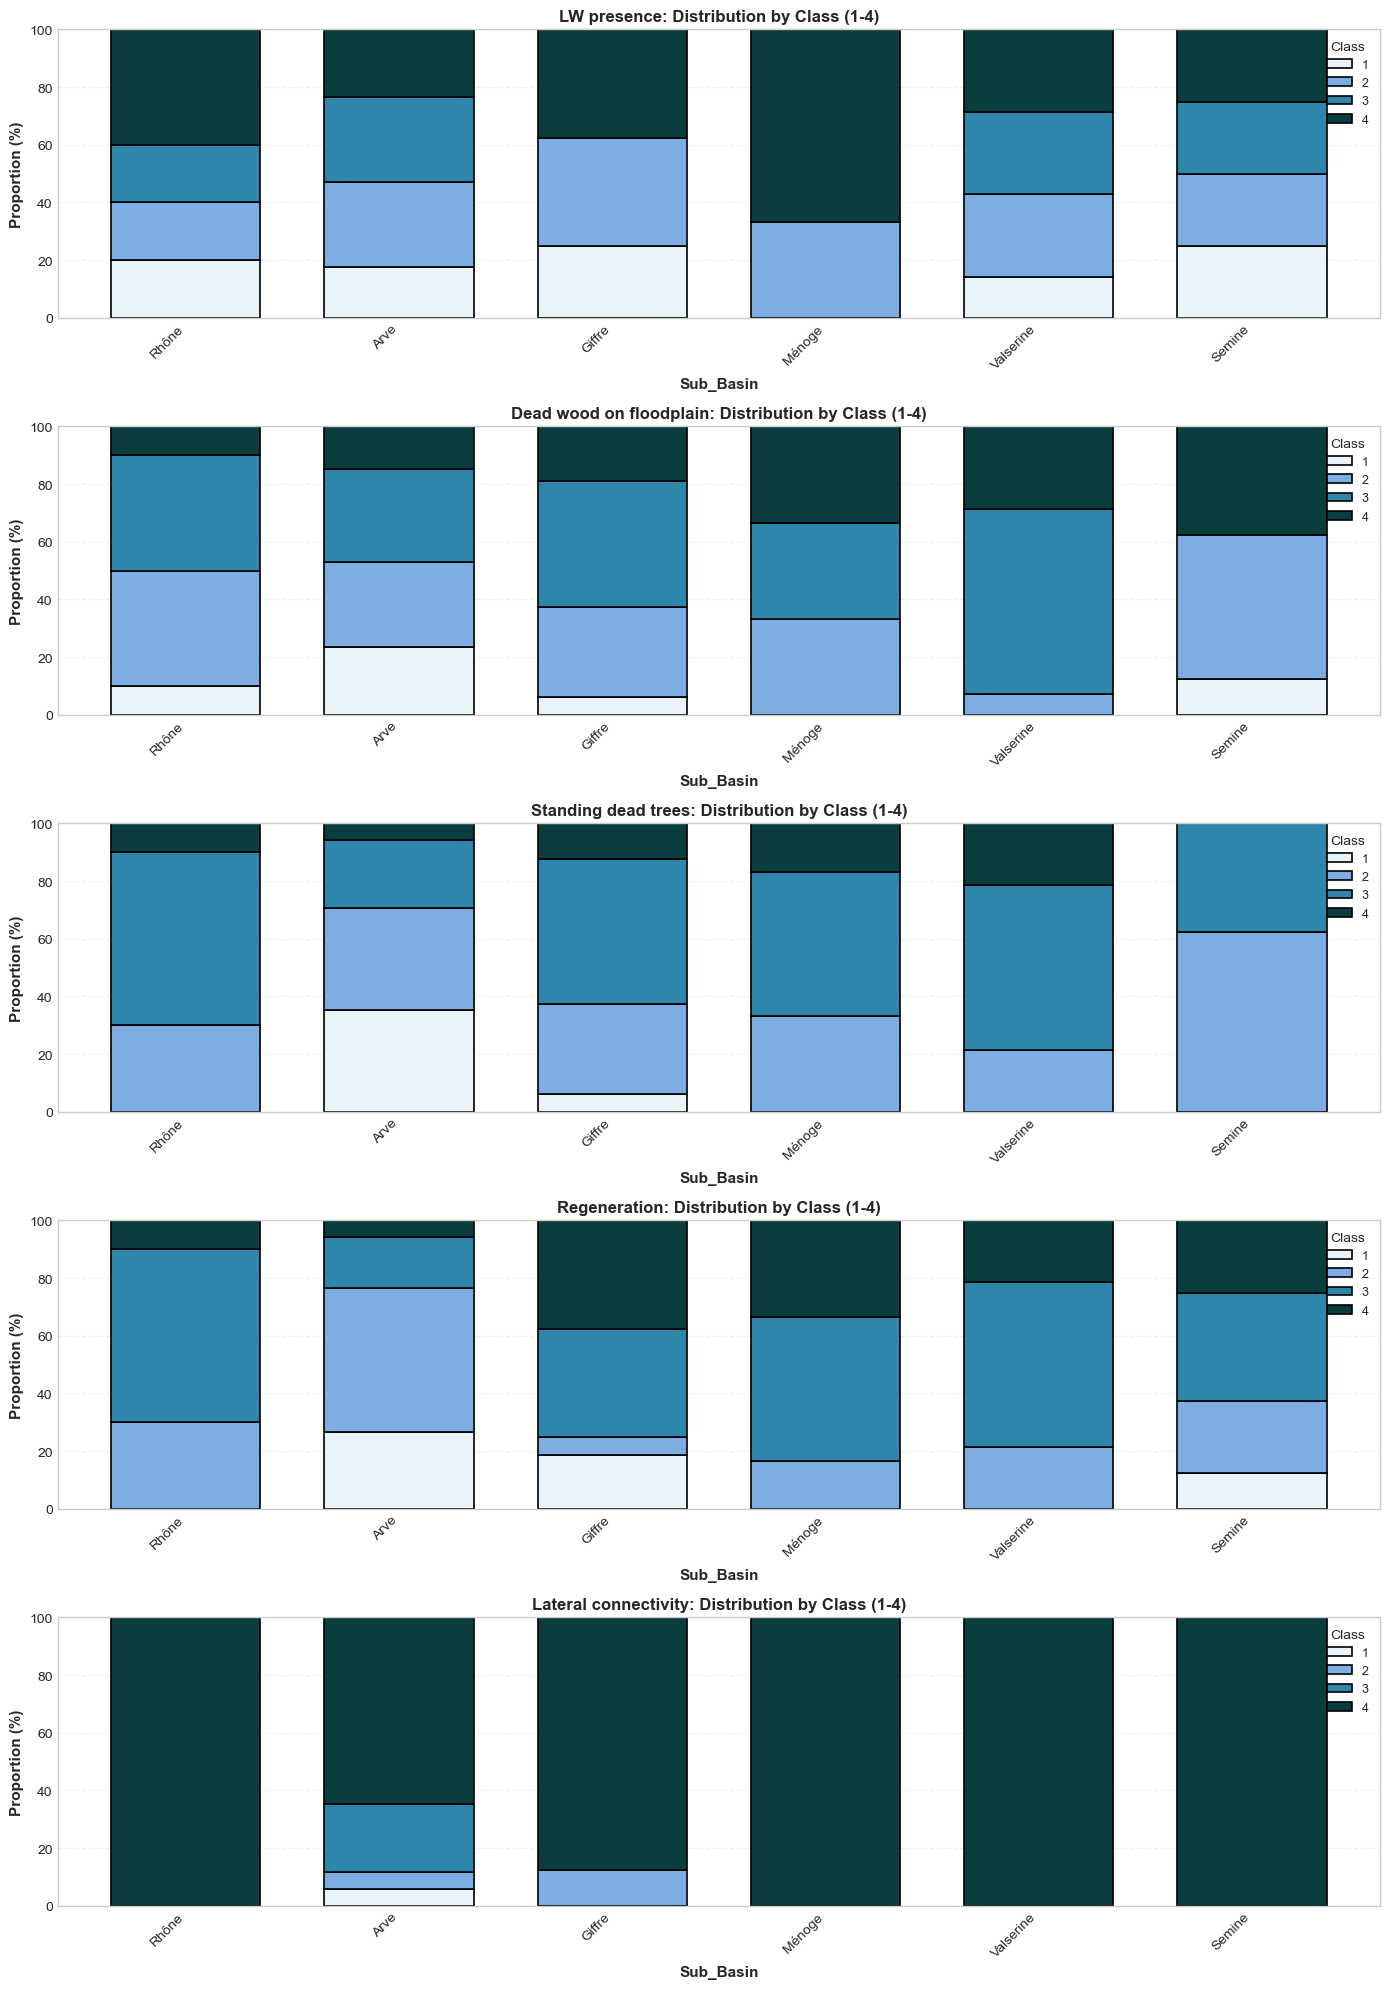


✓ DESCRIPTIVE ANALYSIS COMPLETED


In [48]:
# ============================================================================
# DESCRIPTIVE ANALYSIS BY SUB_BASIN (FINAL)
# Structural and ecological characterization - no causal inference
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.spatial.distance import pdist, squareform

warnings.filterwarnings('ignore')

# --- AUXILIARY FUNCTIONS ---

def safe_percentage_geq(series, threshold):
    """Safely calculate percentage of values >= threshold."""
    data = series.dropna()
    if len(data) == 0:
        return np.nan
    return 100.0 * (data >= threshold).sum() / len(data)

def normalize_subbasin_name(name):
    """Normalize sub-basin name for comparison (removes accents)."""
    name_str = str(name).lower()
    replacements = {'rhône': 'rhone', 'ménoge': 'menoge'}
    for accented, plain in replacements.items():
        name_str = name_str.replace(accented, plain)
    return name_str

def find_subbasin_by_normalized_name(normalized_name, available_basins):
    """Find actual subbasin name matching a normalized name."""
    for sb in available_basins:
        if normalize_subbasin_name(sb) == normalized_name:
            return sb
    return None

def get_preferred_display_name(subbasin_name):
    """Return preferred display name (with accents if available)."""
    norm = normalize_subbasin_name(subbasin_name)
    display_map = {'rhone': 'Rhône', 'menoge': 'Ménoge'}
    return display_map.get(norm, subbasin_name)

def safe_idxmax(series):
    """Safely get index of maximum value, returns None if all NaN."""
    valid = series.dropna()
    if len(valid) == 0:
        return None
    return valid.idxmax()

def round_number(x, decimals=1):
    """Round a number, handling NaN gracefully."""
    if pd.isna(x):
        return np.nan
    return round(x, decimals)

def robust_minmax_normalize(series):
    """Min-max normalize a series robustly, handling NaN and constant values."""
    valid_values = series.dropna()
    if len(valid_values) == 0:
        return pd.Series([0.5] * len(series), index=series.index)
    
    col_min = valid_values.min()
    col_max = valid_values.max()
    col_range = col_max - col_min
    
    if col_range == 0:
        return pd.Series([0.5] * len(series), index=series.index)
    
    normalized = (series - col_min) / col_range
    normalized = normalized.fillna(0.5)
    return normalized

# --- START ANALYSIS ---

print("="*140)
print("DESCRIPTIVE ANALYSIS BY SUB_BASIN: Structural & Ecological Characterization")
print("="*140)

# Define data types and column mapping
ordinal_vars = {
    'LW_Presence': 'LW_Presence',
    'Dead_Wood': 'Dead_Wood',
    'Lat_Connectivity': 'Lat_Connectivity',
    'Standing_Dead_Trees': 'Standing_Dead_Trees',
    'Regeneration': 'Regeneration',
    'Invasive_Ab': 'Invasive_Ab'
}

continuous_vars = {
    'Length': 'Lentgh (m)',
    'Sinuosity': 'Sinuosity',
    'Gradient': 'Gradient (%)',
    'SPI_Width': 'SPI / Width',
    'Distance_outlet': 'Distance to outlet (km)',
    'Width_Mean': 'Width_Mean',
    'Basal_Area': 'Basal_Area (m2/ha)',
    'P50_Height': 'P50_Height',
    'Height_IQR': 'Height_IQR',
    'StructuralIndex': 'StructuralIndex'
}

# Labels for ordinal variable plots
ordinal_plot_labels = {
    'LW_Presence': 'LW presence',
    'Dead_Wood': 'Dead wood on floodplain',
    'Standing_Dead_Trees': 'Standing dead trees',
    'Regeneration': 'Regeneration',
    'Lat_Connectivity': 'Lateral connectivity'
}

# Verify available columns
print("\n✓ Verifying data structure:")
ordinal_available = {k: v for k, v in ordinal_vars.items() if v in df.columns}
continuous_available = {k: v for k, v in continuous_vars.items() if v in df.columns}
print(f"  Ordinal variables available: {len(ordinal_available)}")
print(f"  Continuous variables available: {len(continuous_available)}")

# Define and order sub-basins with accent handling
subbasin_order_normalized = ['rhone', 'arve', 'giffre', 'menoge', 'valserine', 'semine']
existing_subbasins_orig = []
existing_subbasins_normalized = set()

for sb in df['Sub_Basin'].unique():
    sb_norm = normalize_subbasin_name(sb)
    if sb_norm in subbasin_order_normalized:
        if sb_norm not in existing_subbasins_normalized:
            existing_subbasins_orig.append(sb)
            existing_subbasins_normalized.add(sb_norm)

ordered_subbasins = sorted(existing_subbasins_orig, 
                          key=lambda x: subbasin_order_normalized.index(normalize_subbasin_name(x)))

other_subbasins = [sb for sb in df['Sub_Basin'].unique() if sb not in ordered_subbasins]
ordered_subbasins = ordered_subbasins + sorted(other_subbasins)

print(f"\n✓ Sub_Basins found (ordered): {ordered_subbasins}")

# ============================================================================
# 1. GENERAL SUMMARY TABLE BY SUB_BASIN
# ============================================================================
print("\n" + "="*140)
print("1. GENERAL SUMMARY TABLE BY SUB_BASIN")
print("="*140)

summary_data = []

for subbasin in ordered_subbasins:
    df_sb = df[df['Sub_Basin'] == subbasin].copy()
    n_total = len(df_sb)
    
    row = {'Sub_Basin': subbasin, 'n': n_total}
    
    for internal_name, col_name in ordinal_available.items():
        data = df_sb[col_name].dropna()
        if len(data) > 0:
            median_val = data.median()
            q1 = data.quantile(0.25)
            q3 = data.quantile(0.75)
            iqr_val = q3 - q1
            pct_ge3 = safe_percentage_geq(df_sb[col_name], 3)
            
            row[f'{internal_name}_median'] = median_val
            row[f'{internal_name}_IQR'] = iqr_val
            row[f'{internal_name}_%>=3'] = pct_ge3
        else:
            row[f'{internal_name}_median'] = np.nan
            row[f'{internal_name}_IQR'] = np.nan
            row[f'{internal_name}_%>=3'] = np.nan
    
    for internal_name, col_name in continuous_available.items():
        data = df_sb[col_name].dropna()
        if len(data) > 0:
            n_valid = len(data)
            mean_val = data.mean()
            std_val = data.std()
            median_val = data.median()
            q1 = data.quantile(0.25)
            q3 = data.quantile(0.75)
            iqr_val = q3 - q1
            
            row[f'{internal_name}_n'] = n_valid
            row[f'{internal_name}_mean'] = mean_val
            row[f'{internal_name}_std'] = std_val
            row[f'{internal_name}_median'] = median_val
            row[f'{internal_name}_IQR'] = iqr_val
        else:
            row[f'{internal_name}_n'] = 0
            row[f'{internal_name}_mean'] = np.nan
            row[f'{internal_name}_std'] = np.nan
            row[f'{internal_name}_median'] = np.nan
            row[f'{internal_name}_IQR'] = np.nan
    
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)

# Print with rounded display
print("\n--- ORDINAL VARIABLES (median, IQR, % >= 3) ---")
for internal_name in ordinal_available.keys():
    display_cols = ['Sub_Basin', f'{internal_name}_median', f'{internal_name}_IQR', f'{internal_name}_%>=3']
    df_display = df_summary[display_cols].copy()
    for col in display_cols[1:]:
        df_display[col] = df_display[col].apply(lambda x: round_number(x, 1))
    print(f"\n{internal_name}:")
    print(df_display.to_string(index=False))

print("\n\n--- CONTINUOUS VARIABLES (n, mean±std, median, IQR) ---")
for internal_name in continuous_available.keys():
    display_cols = ['Sub_Basin', f'{internal_name}_n', f'{internal_name}_mean', f'{internal_name}_std', f'{internal_name}_median', f'{internal_name}_IQR']
    df_display = df_summary[display_cols].copy()
    for col in display_cols[2:]:
        df_display[col] = df_display[col].apply(lambda x: round_number(x, 2))
    print(f"\n{internal_name}:")
    print(df_display.to_string(index=False))

# ============================================================================
# 2. SYNTHETIC ECOLOGICAL-FUNCTIONAL TABLE
# ============================================================================
print("\n\n" + "="*140)
print("2. SYNTHETIC ECOLOGICAL-FUNCTIONAL TABLE BY SUB_BASIN")
print("="*140)

synthetic_data = []

for subbasin in ordered_subbasins:
    df_sb = df[df['Sub_Basin'] == subbasin].copy()
    
    row = {'Sub_Basin': subbasin}
    row['Dead_Wood_%>=3'] = safe_percentage_geq(df_sb['Dead_Wood'], 3)
    row['Standing_Dead_Trees_%>=3'] = safe_percentage_geq(df_sb['Standing_Dead_Trees'], 3)
    row['Regeneration_%>=3'] = safe_percentage_geq(df_sb['Regeneration'], 3)
    row['Lat_Connectivity_%>=3'] = safe_percentage_geq(df_sb['Lat_Connectivity'], 3)
    row['Invasive_Ab_%>=3'] = safe_percentage_geq(df_sb['Invasive_Ab'], 3)
    row['LW_Presence_%>=2'] = safe_percentage_geq(df_sb['LW_Presence'], 2)
    row['Basal_Area_median'] = df_sb['Basal_Area (m2/ha)'].median()
    row['StructuralIndex_median'] = df_sb['StructuralIndex'].median()
    row['P50_Height_median'] = df_sb['P50_Height'].median()
    row['Height_IQR_median'] = df_sb['Height_IQR'].median()
    
    synthetic_data.append(row)

df_synthetic = pd.DataFrame(synthetic_data)

df_synthetic_display = df_synthetic.copy()
df_synthetic_display['Sub_Basin'] = df_synthetic_display['Sub_Basin'].apply(get_preferred_display_name)
for col in df_synthetic_display.columns:
    if col != 'Sub_Basin':
        df_synthetic_display[col] = df_synthetic_display[col].apply(lambda x: round_number(x, 1))

print("\nEcological-Functional Profile by Sub_Basin:")
print(df_synthetic_display.to_string(index=False))

# ============================================================================
# 3. HEATMAP: NORMALIZED BY COLUMN (MIN-MAX SCALING)
# ============================================================================
print("\n" + "="*140)
print("3. HEATMAP: COMPARATIVE ECOLOGICAL-FUNCTIONAL PROFILES BY SUB_BASIN")
print("="*140)

heatmap_cols = [
    'Dead_Wood_%>=3', 'Standing_Dead_Trees_%>=3', 'Regeneration_%>=3',
    'Lat_Connectivity_%>=3', 'LW_Presence_%>=2',
    'Basal_Area_median', 'StructuralIndex_median', 'P50_Height_median', 'Height_IQR_median'
]

heatmap_labels = [
    'Dead wood ≥3 (%)',
    'Standing dead trees ≥3 (%)',
    'Regeneration ≥3 (%)',
    'Lateral connectivity ≥3 (%)',
    'LW presence ≥2 (%)',
    'Basal area (median)',
    'Structural index (median)',
    'P50 height (median)',
    'Height IQR (median)'
]

df_heatmap = df_synthetic.set_index('Sub_Basin')[heatmap_cols].copy()

# Robust min-max normalization
df_heatmap_norm = pd.DataFrame(index=df_heatmap.index, columns=df_heatmap.columns)
for col in heatmap_cols:
    df_heatmap_norm[col] = robust_minmax_normalize(df_heatmap[col])

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(df_heatmap_norm.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(heatmap_cols)))
ax.set_yticks(np.arange(len(df_heatmap_norm.index)))
ax.set_xticklabels(heatmap_labels, fontsize=10, rotation=45, ha='right')
ax.set_yticklabels([get_preferred_display_name(sb) for sb in df_heatmap_norm.index], fontsize=11, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Normalized value (min-max scaling)')

for i in range(len(df_heatmap_norm.index)):
    for j in range(len(heatmap_cols)):
        val = df_heatmap.iloc[i, j]
        if pd.isna(val):
            text_str = 'NA'
            color_text = 'gray'
        else:
            text_str = f'{val:.1f}'
            color_text = 'white' if df_heatmap_norm.iloc[i, j] > 0.7 else 'black'
        
        ax.text(j, i, text_str, ha='center', va='center', 
               color=color_text, fontsize=8, fontweight='bold')

ax.set_title('Comparative ecological-functional profiles by sub-basin', 
            fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(get_output_path('01_Heatmap_EcologicalFunctionalProfiles.png', subfolder='figures'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ============================================================================
# 4. STACKED BAR CHARTS FOR ORDINAL VARIABLES
# ============================================================================
print("\n\n" + "="*140)
print("4. STACKED BAR CHARTS: DISTRIBUTION OF ORDINAL VARIABLES BY SUB_BASIN")
print("="*140)

ordinal_plot_vars = ['LW_Presence', 'Dead_Wood', 'Standing_Dead_Trees', 'Regeneration', 'Lat_Connectivity']

fig, axes = plt.subplots(len(ordinal_plot_vars), 1, figsize=(14, 4*len(ordinal_plot_vars)))
if len(ordinal_plot_vars) == 1:
    axes = [axes]

for idx, var_name in enumerate(ordinal_plot_vars):
    if var_name not in df.columns:
        print(f"  Skipping {var_name}: not in dataframe")
        continue
    
    ax = axes[idx]
    
    dist_data = []
    for subbasin in ordered_subbasins:
        df_sb = df[df['Sub_Basin'] == subbasin]
        counts = df_sb[var_name].value_counts().sort_index()
        total = len(df_sb[df_sb[var_name].notna()])
        proportions = (counts / total * 100) if total > 0 else counts
        dist_data.append(proportions)
    
    df_dist = pd.DataFrame(dist_data, index=ordered_subbasins).fillna(0)
    
    for col in [1, 2, 3, 4]:
        if col not in df_dist.columns:
            df_dist[col] = 0
    
    df_dist = df_dist[[1, 2, 3, 4]]
    
    df_dist.plot(kind='bar', stacked=True, ax=ax, width=0.7,
                color=['#E8F4F8', '#7DADE2', '#2E86AB', '#0A3E3E'],
                edgecolor='black', linewidth=1.2)
    
    plot_label = ordinal_plot_labels.get(var_name, var_name)
    ax.set_title(f'{plot_label}: Distribution by Class (1-4)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sub_Basin', fontsize=11, fontweight='bold')
    ax.set_ylabel('Proportion (%)', fontsize=11, fontweight='bold')
    ax.legend(title='Class', labels=['1', '2', '3', '4'], loc='upper right', fontsize=9)
    ax.set_xticklabels([get_preferred_display_name(sb) for sb in ordered_subbasins], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig(get_output_path('02_StackedBarCharts_OrdinalVariables.png', subfolder='figures'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*140)
print("✓ DESCRIPTIVE ANALYSIS COMPLETED")
print("="*140)

In [49]:
print('\n' + '='*80)
print('MODEL GROUPS: Dead_Wood vs LW_Presence')
print('='*80)

# Define predictors for each target variable
model_configs = {
    'Dead_Wood': {
        'target': 'Dead_Wood',
        'predictors': [
            'Basal_Area (m2/ha)',
            'P50_Height',
            'Height_IQR',
            'StructuralIndex',
            'Invasive_Ab',
            'Standing_Dead_Trees',
            'Regeneration'
        ]
    },
    'LW_Presence': {
        'target': 'LW_Presence',
        'predictors': [
            'Standing_Dead_Trees',
            'Regeneration',
            'Basal_Area (m2/ha)',
            'StructuralIndex',
            'P50_Height',
            'Dead_Wood',
            'Height_IQR',
            'Invasive_Ab',
            'Gradient (%)',
            'SPI / Width',
            'Distance to outlet (km)',
            'Sinuosity'
        ]
    }
}

# Display model configurations
for model_name, config in model_configs.items():
    print(f'\n{model_name}:')
    print(f'  Target: {config["target"]}')
    print(f'  Predictors ({len(config["predictors"])}):')
    for pred in config["predictors"]:
        print(f'    - {pred}')

# Verify available columns in dataframe
print(f'\n\nValidating predictors against available columns:')
available_cols = set(df.columns)

for model_name, config in model_configs.items():
    print(f'\n{model_name}:')
    missing = []
    available = []
    
    for pred in config["predictors"]:
        if pred in available_cols:
            available.append(pred)
        else:
            missing.append(pred)
    
    print(f'  ✓ Available: {len(available)}/{len(config["predictors"])}')
    if missing:
        print(f'  ✗ Missing: {len(missing)}')
        for col in missing:
            print(f'    - {col}')
    else:
        print(f'  ✓ All predictors available!')

print(f'\n✓ Model configurations ready for analysis')


MODEL GROUPS: Dead_Wood vs LW_Presence

Dead_Wood:
  Target: Dead_Wood
  Predictors (7):
    - Basal_Area (m2/ha)
    - P50_Height
    - Height_IQR
    - StructuralIndex
    - Invasive_Ab
    - Standing_Dead_Trees
    - Regeneration

LW_Presence:
  Target: LW_Presence
  Predictors (12):
    - Standing_Dead_Trees
    - Regeneration
    - Basal_Area (m2/ha)
    - StructuralIndex
    - P50_Height
    - Dead_Wood
    - Height_IQR
    - Invasive_Ab
    - Gradient (%)
    - SPI / Width
    - Distance to outlet (km)
    - Sinuosity


Validating predictors against available columns:

Dead_Wood:
  ✓ Available: 7/7
  ✓ All predictors available!

LW_Presence:
  ✓ Available: 12/12
  ✓ All predictors available!

✓ Model configurations ready for analysis


In [50]:
print('\n' + '='*120)
print('PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)')
print('='*120)

from scipy.stats import spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# ===================== PREDICTOR TYPES =====================
predictor_types = {
    # Dead_Wood
    'Basal_Area (m2/ha)': 'continuous',
    'P50_Height': 'continuous',
    'Height_IQR': 'continuous',
    'StructuralIndex': 'continuous',
    'Invasive_Ab': 'discrete_count',
    'Standing_Dead_Trees': 'ordinal_1_4',
    'Regeneration': 'ordinal_1_4',
    # LW_Presence
    'Gradient (%)': 'continuous',
    'SPI / Width': 'continuous',
    'Distance to outlet (km)': 'continuous',
    'Sinuosity': 'continuous',
}

# ===================== HELPER FUNCTIONS =====================
def calculate_epsilon_squared(h_stat, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis
    Returns max(0, ...) to avoid negative values"""
    return max((h_stat - k + 1) / (n - k), 0)

def assign_visual_pattern(abs_rho, kw_p, eps_sq):
    """Assign visual pattern based on explicit statistical thresholds"""
    if abs_rho >= 0.50 and kw_p < 0.05 and eps_sq >= 0.08:
        return 'strong_pattern'
    elif 0.30 <= abs_rho < 0.50 and kw_p < 0.05 and eps_sq >= 0.02:
        return 'moderate_pattern'
    elif 0.10 <= abs_rho < 0.30 and (kw_p < 0.10 or eps_sq >= 0.01):
        return 'weak_pattern'
    elif abs_rho < 0.10 and kw_p > 0.05:
        return 'no_clear_pattern'
    else:
        return 'difficult_to_assess'

def get_pattern_note(pattern, abs_rho, kw_p, eps_sq, n_unique):
    """Get brief explanation for pattern assignment"""
    if pattern == 'strong_pattern':
        return 'clear monotonic gradient and/or reasonable class separation'
    elif pattern == 'moderate_pattern':
        return 'visible trend with overlap among classes'
    elif pattern == 'weak_pattern':
        return 'weak trend with substantial overlap'
    elif pattern == 'no_clear_pattern':
        return 'no clear gradient or class separation'
    else:  # difficult_to_assess
        if n_unique <= 2 or eps_sq < 0.001:
            return 'low variability or unbalanced categories'
        else:
            return 'mixed statistical signal'

def classify_evidence(kw_p, abs_rho, pattern, eps_sq):
    """Evidence classification based on Spearman + Kruskal-Wallis coherence"""
    # strong: significant with moderate-to-strong monotonicity
    if kw_p < 0.05 and abs_rho > 0.40:
        return 'strong_evidence'
    # moderate: significant with weak-to-moderate monotonicity, OR very small p with weak monotonicity
    elif kw_p < 0.05 and abs_rho > 0.20:
        return 'moderate_evidence'
    elif (kw_p < 0.10 or abs_rho > 0.15) and eps_sq > 0.01:
        return 'moderate_evidence'
    # weak: suggestive signal but not quite reaching moderate threshold
    elif kw_p < 0.10 or abs_rho > 0.15:
        return 'weak_evidence'
    else:
        return 'ambiguous_evidence'

print(f'\n✓ Framework configured:')
print(f'  - Spearman rank correlation (monotonic association)')
print(f'  - Kruskal-Wallis H-test (group differences)')
print(f'  - Epsilon-squared effect size (non-parametric)')
print(f'  - Ranking based on Spearman ρ + Kruskal p-value')

# ==================== DEAD_WOOD MODEL ====================
print(f'\n' + '='*120)
print('DEAD_WOOD MODEL: Univariate Predictor Ranking')
print('='*120)

dead_wood_response = 'Dead_Wood'
dead_wood_preds = ['Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex', 
                    'Invasive_Ab', 'Standing_Dead_Trees', 'Regeneration']

dead_wood_preds_avail = [p for p in dead_wood_preds if p in df.columns]
df_dw = df[[dead_wood_response] + dead_wood_preds_avail].dropna()

print(f'\n✓ Analyzing {len(dead_wood_preds_avail)} predictors | {len(df_dw)} complete observations')
print(f'  Predictors: {", ".join(dead_wood_preds_avail)}')

results_dw = []

for pred in dead_wood_preds_avail:
    X = df_dw[pred].values
    y = df_dw[dead_wood_response].values
    n = len(y)
    k = len(np.unique(y))
    
    # 1. Spearman rank correlation
    rho, p_spear = spearmanr(X, y)
    direction = 'positive' if rho > 0.05 else ('negative' if rho < -0.05 else 'near_zero')
    
    # 2. Kruskal-Wallis H test
    groups = [X[y == val] for val in np.unique(y)]
    h_stat, p_kw = kruskal(*groups)
    
    # 3. Effect size: Epsilon-squared
    eps_sq = calculate_epsilon_squared(h_stat, n, k)
    
    # 4. Visual pattern based on combined criteria
    pattern = assign_visual_pattern(abs(rho), p_kw, eps_sq)
    n_unique_pred = len(np.unique(X))
    pattern_note = get_pattern_note(pattern, abs(rho), p_kw, eps_sq, n_unique_pred)
    
    # 5. Evidence classification
    evidence = classify_evidence(p_kw, abs(rho), pattern, eps_sq)
    
    # 6. Ranking score: transparent formula combining monotonicity + group separation
    # score = (|rho| × 10) + (-log10(Kruskal_p) × 5)
    score = abs(rho) * 10 + (-np.log10(max(p_kw, 1e-10))) * 5
    
    results_dw.append({
        'Predictor': pred,
        'Predictor_type': predictor_types.get(pred, 'unknown'),
        'Spearman_rho': rho,
        'Spearman_p': p_spear,
        'Direction': direction,
        'Kruskal_stat': h_stat,
        'Kruskal_p': p_kw,
        'Effect_size': eps_sq,
        'Visual_pattern': pattern,
        'Visual_pattern_note': pattern_note,
        'Evidence_class': evidence,
        'Ranking_score': score
    })

df_rank_dw = pd.DataFrame(results_dw).sort_values('Ranking_score', ascending=False).reset_index(drop=True)
df_rank_dw['Ranking_position'] = range(1, len(df_rank_dw) + 1)

print(f'\n✓ Ranking summary:')
print(df_rank_dw[['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Kruskal_p', 'Evidence_class']].to_string(index=False))

# Export
path_dw = get_output_path('PASO3_Ranking_Dead_Wood.csv')
# Reorder columns for final export
col_order_dw = ['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Spearman_p', 
                 'Direction', 'Kruskal_stat', 'Kruskal_p', 'Effect_size', 'Visual_pattern', 
                 'Visual_pattern_note', 'Evidence_class', 'Ranking_score']
df_rank_dw[col_order_dw].to_csv(path_dw, index=False)
print(f'\n✓ Exported to: {path_dw}')

# ==================== LW_PRESENCE MODEL ====================
print(f'\n' + '='*120)
print('LW_PRESENCE MODEL: Univariate Predictor Ranking')
print('='*120)

lw_response = 'LW_Presence'
lw_preds = ['Standing_Dead_Trees', 'Regeneration', 'Basal_Area (m2/ha)', 'StructuralIndex',
            'P50_Height', 'Height_IQR', 'Invasive_Ab', 'Gradient (%)', 'SPI / Width',
            'Distance to outlet (km)', 'Sinuosity', 'Dead_Wood']

lw_preds_avail = [p for p in lw_preds if p in df.columns]
df_lw = df[[lw_response] + lw_preds_avail].dropna()

print(f'\n✓ Analyzing {len(lw_preds_avail)} predictors | {len(df_lw)} complete observations')
print(f'  Predictors: {", ".join(lw_preds_avail)}')

results_lw = []

for pred in lw_preds_avail:
    X = df_lw[pred].values
    y = df_lw[lw_response].values
    n = len(y)
    k = len(np.unique(y))
    
    # 1. Spearman rank correlation
    rho, p_spear = spearmanr(X, y)
    direction = 'positive' if rho > 0.05 else ('negative' if rho < -0.05 else 'near_zero')
    
    # 2. Kruskal-Wallis H test
    groups = [X[y == val] for val in np.unique(y)]
    h_stat, p_kw = kruskal(*groups)
    
    # 3. Effect size: Epsilon-squared
    eps_sq = calculate_epsilon_squared(h_stat, n, k)
    
    # 4. Visual pattern based on combined criteria
    pattern = assign_visual_pattern(abs(rho), p_kw, eps_sq)
    n_unique_pred = len(np.unique(X))
    pattern_note = get_pattern_note(pattern, abs(rho), p_kw, eps_sq, n_unique_pred)
    
    # 5. Evidence classification
    evidence = classify_evidence(p_kw, abs(rho), pattern, eps_sq)
    
    # 6. Ranking score
    score = abs(rho) * 10 + (-np.log10(max(p_kw, 1e-10))) * 5
    
    results_lw.append({
        'Predictor': pred,
        'Predictor_type': predictor_types.get(pred, 'unknown'),
        'Spearman_rho': rho,
        'Spearman_p': p_spear,
        'Direction': direction,
        'Kruskal_stat': h_stat,
        'Kruskal_p': p_kw,
        'Effect_size': eps_sq,
        'Visual_pattern': pattern,
        'Visual_pattern_note': pattern_note,
        'Evidence_class': evidence,
        'Ranking_score': score
    })

df_rank_lw = pd.DataFrame(results_lw).sort_values('Ranking_score', ascending=False).reset_index(drop=True)
df_rank_lw['Ranking_position'] = range(1, len(df_rank_lw) + 1)

print(f'\n✓ Ranking summary:')
print(df_rank_lw[['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Kruskal_p', 'Evidence_class']].to_string(index=False))

# Export
path_lw = get_output_path('PASO3_Ranking_LW_Presence.csv')
col_order_lw = ['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Spearman_p',
                'Direction', 'Kruskal_stat', 'Kruskal_p', 'Effect_size', 'Visual_pattern',
                'Visual_pattern_note', 'Evidence_class', 'Ranking_score']
df_rank_lw[col_order_lw].to_csv(path_lw, index=False)
print(f'\n✓ Exported to: {path_lw}')

# ===================== SUMMARY & METHODOLOGY =====================
print(f'\n' + '='*120)
print('RANKING METHODOLOGY & SUMMARY')
print('='*120)

print(f'\n✓ RANKING SCORE FORMULA:')
print(f'  score = (|Spearman_rho| × 10) + (-log10(Kruskal_p) × 5)')
print(f'\n  Rationale:')
print(f'    - First term: weights monotonic correlation strength [0, 10]')
print(f'    - Second term: weights group separation significance [0, ∞)')
print(f'    - Result: transparent, reproducible ordering by evidence strength')
print(f'\n  This is NOT a formal inferential statistic.')
print(f'  It serves only to rank predictors by univariate association with targets.')

print(f'\n✓ TOP PREDICTORS FOR DEAD_WOOD:')
for i, row in df_rank_dw.head(5).iterrows():
    pos = i + 1
    print(f'  {pos}. {row["Predictor"]:30s} | rho={row["Spearman_rho"]:7.4f} (p={row["Spearman_p"]:.2e}) | Kruskal p={row["Kruskal_p"]:.2e} | {row["Evidence_class"]}')

print(f'\n✓ TOP PREDICTORS FOR LW_PRESENCE:')
for i, row in df_rank_lw.head(5).iterrows():
    pos = i + 1
    print(f'  {pos}. {row["Predictor"]:30s} | rho={row["Spearman_rho"]:7.4f} (p={row["Spearman_p"]:.2e}) | Kruskal p={row["Kruskal_p"]:.2e} | {row["Evidence_class"]}')

print(f'\n✓ EXPORTS COMPLETED:')
print(f'  - {path_dw.name}')
print(f'  - {path_lw.name}')


PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)

✓ Framework configured:
  - Spearman rank correlation (monotonic association)
  - Kruskal-Wallis H-test (group differences)
  - Epsilon-squared effect size (non-parametric)
  - Ranking based on Spearman ρ + Kruskal p-value

DEAD_WOOD MODEL: Univariate Predictor Ranking

✓ Analyzing 7 predictors | 88 complete observations
  Predictors: Basal_Area (m2/ha), P50_Height, Height_IQR, StructuralIndex, Invasive_Ab, Standing_Dead_Trees, Regeneration

✓ Ranking summary:
 Ranking_position           Predictor Predictor_type  Spearman_rho  Kruskal_p     Evidence_class
                1 Standing_Dead_Trees    ordinal_1_4      0.537516   0.000004    strong_evidence
                2  Basal_Area (m2/ha)     continuous      0.490141   0.000008    strong_evidence
                3        Regeneration    ordinal_1_4      0.346874   0.008412  moderate_evidence
                4          Height_IQR     continuous      0.194687   0.007235  moderate_evi


BOXPLOTS: Predictor Distributions Ranked by Evidence Strength

✓ Dead_Wood Model: 7 predictors


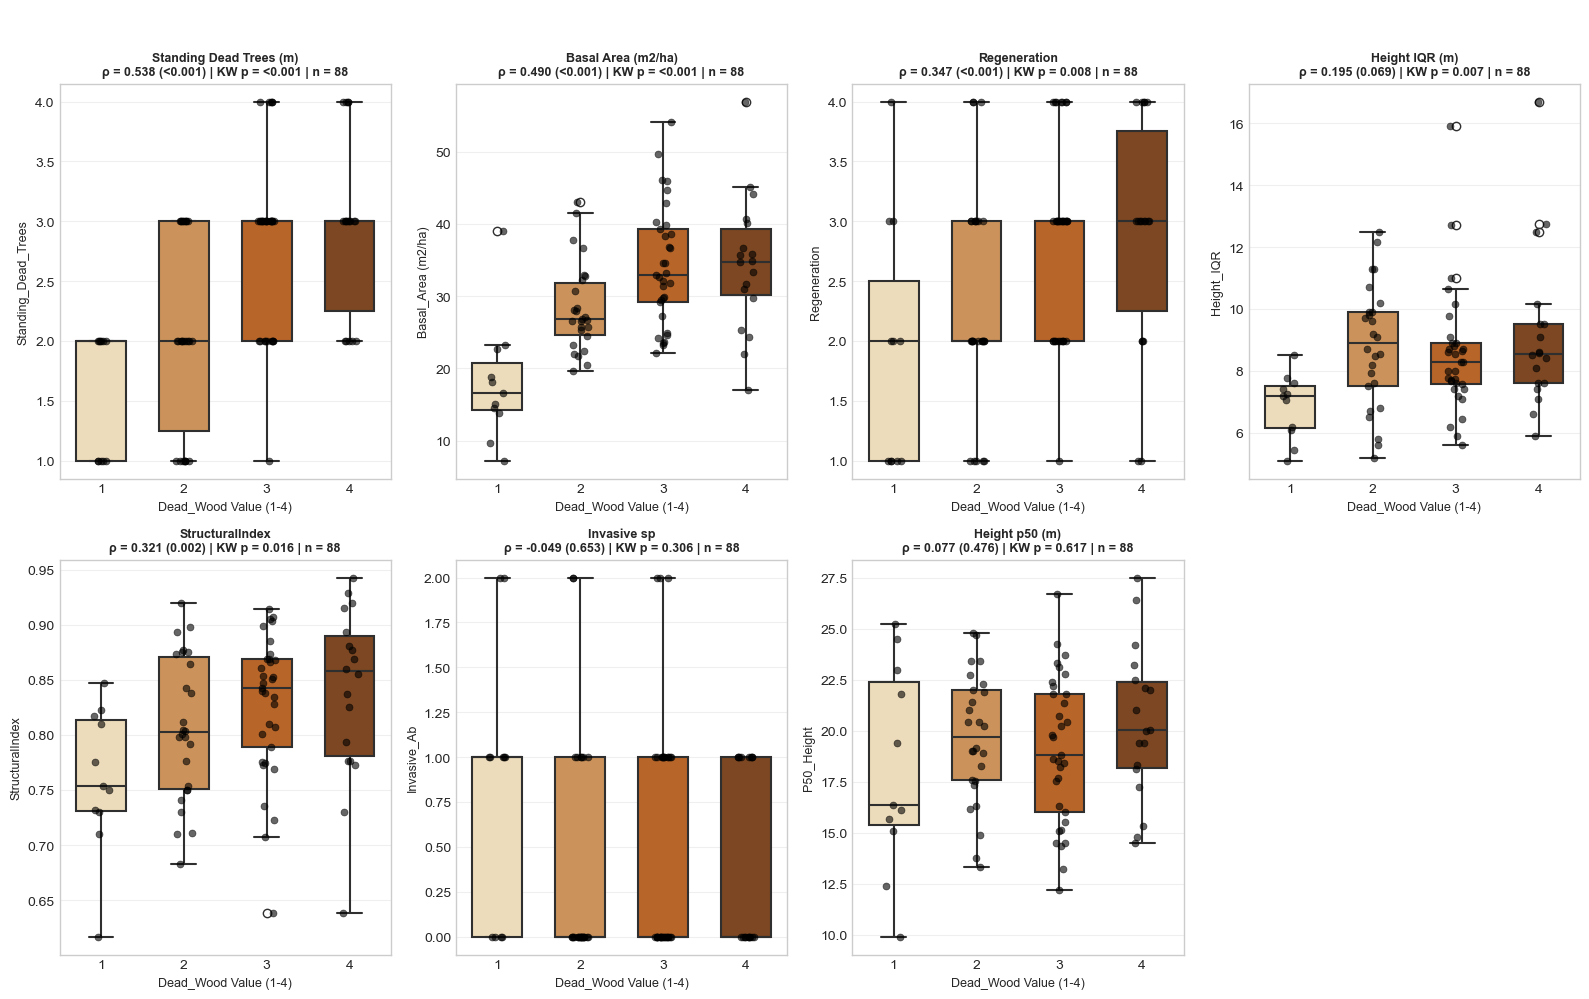


✓ Dead_Wood boxplots created: 7 predictors displayed

✓ LW_Presence Model: 12 predictors


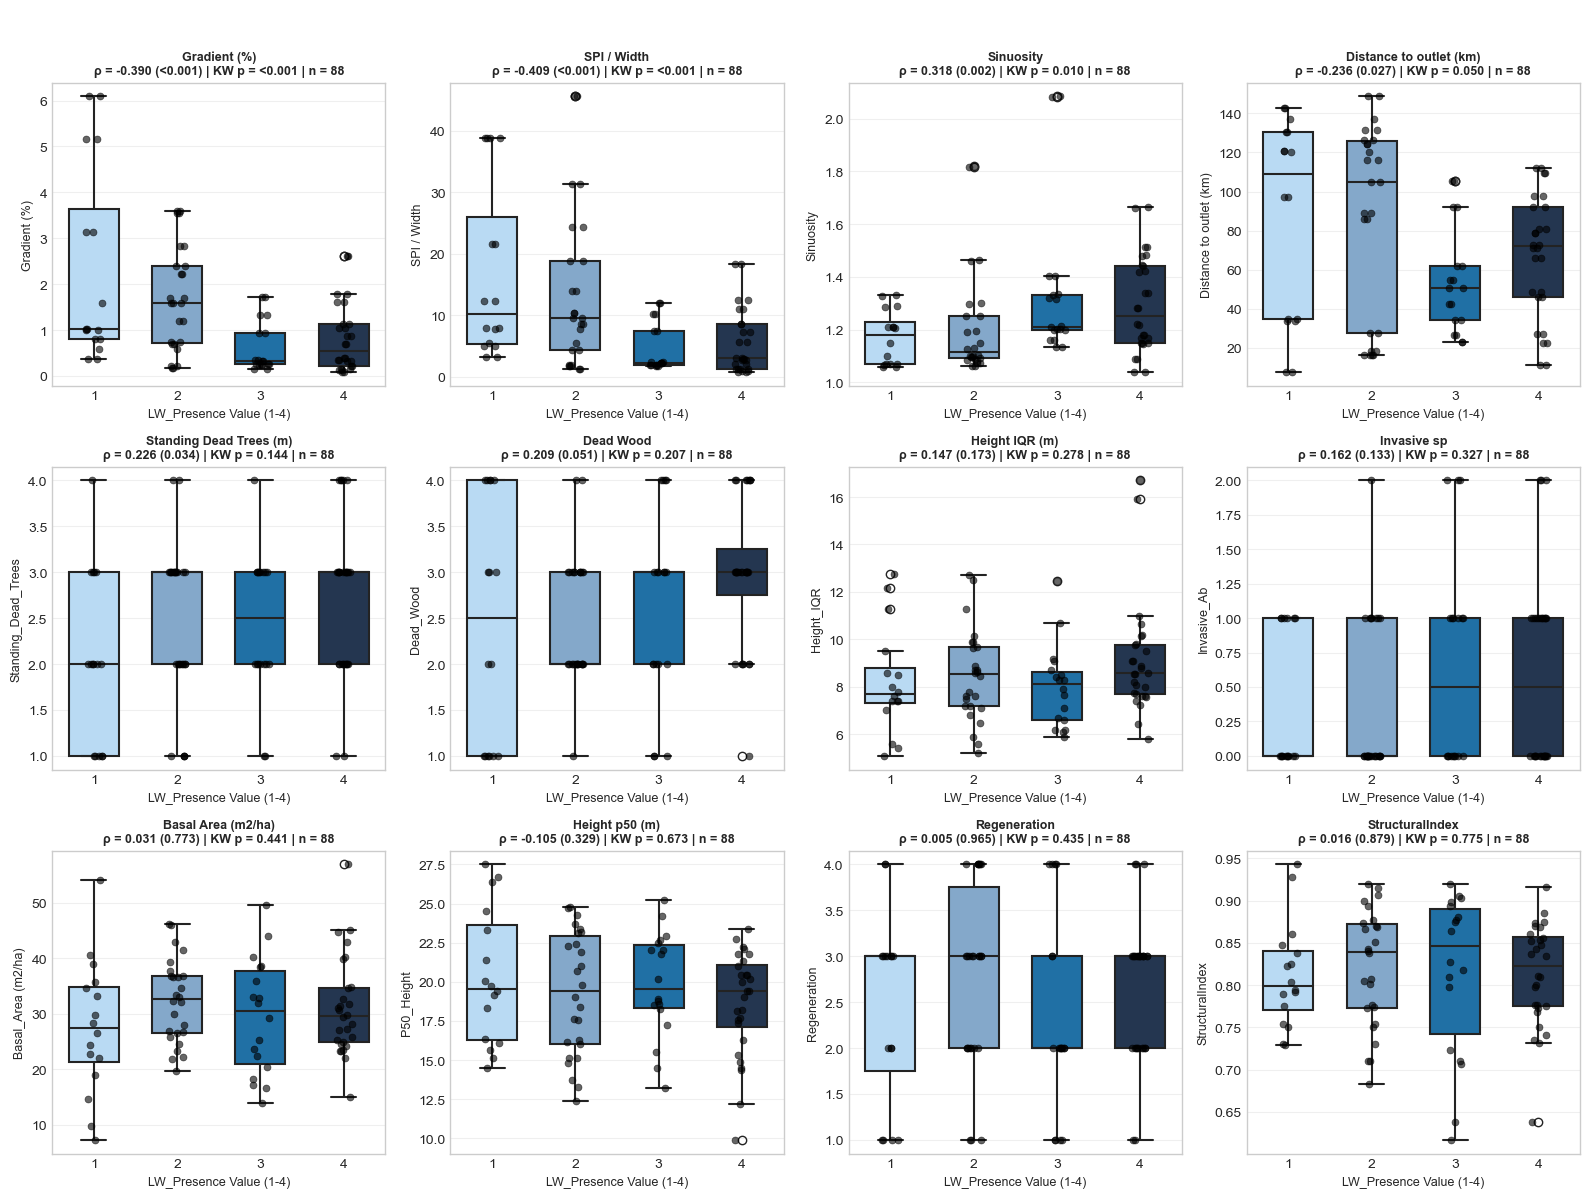


✓ LW_Presence boxplots created: 12 predictors displayed

✓ All visualizations completed. Compare distributions with ranking evidence.


In [51]:

# ===================== PASO 3 VISUALIZATION: BOXPLOTS BY RANKING =====================
print('\n' + '='*120)
print('BOXPLOTS: Predictor Distributions Ranked by Evidence Strength')
print('='*120)

# ==================== DEAD_WOOD BOXPLOTS ====================
print(f'\n✓ Dead_Wood Model: {len(df_rank_dw)} predictors')

# Variable name mapping for better display with units
var_name_map = {
    'Standing_Dead_Trees': 'Standing Dead Trees (m)',
    'Height_IQR': 'Height IQR (m)',
    'Invasive_Ab': 'Invasive sp',
    'P50_Height': 'Height p50 (m)',
}

# Build palette list for Dead_Wood (values 1-4)
dw_palette_for_boxplot = [dw_class_colors.get(i, '#cccccc') for i in [1, 2, 3, 4]]

fig_dw, axes_dw = plt.subplots(2, 4, figsize=(16, 10))
axes_dw = axes_dw.flatten()

for idx, (i, row) in enumerate(df_rank_dw.iterrows()):
    if idx >= len(axes_dw):
        break
    
    pred = row['Predictor']
    rho = row['Spearman_rho']
    p_spear = row['Spearman_p']
    p_kw = row['Kruskal_p']
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    
    # Prepare data
    plot_data = df[[dead_wood_response, pred]].dropna()
    n_samples = len(plot_data)
    
    if n_samples > 0:
        # Create boxplot with custom palette
        sns.boxplot(data=plot_data, x=dead_wood_response, y=pred, ax=axes_dw[idx],
                   palette=dw_palette_for_boxplot, order=['1', '2', '3', '4'],
                   width=0.6, linewidth=1.5, patch_artist=True)
        
        # Overlay individual points
        sns.stripplot(data=plot_data, x=dead_wood_response, y=pred, ax=axes_dw[idx],
                     order=['1', '2', '3', '4'], size=5, alpha=0.6,
                     color='black', jitter=True, edgecolor='gray', linewidth=0.5)
        
        axes_dw[idx].set_xlabel('Dead_Wood Value (1-4)', fontsize=9)
        axes_dw[idx].set_ylabel(pred, fontsize=9)
        
        # Format p-values with <0.001 threshold
        spear_p_str = '<0.001' if p_spear < 0.001 else f'{p_spear:.3f}'
        kw_p_str = '<0.001' if p_kw < 0.001 else f'{p_kw:.3f}'
        
        # Get formatted variable name (with units) or default to pred with dashes replaced by spaces
        pred_display = var_name_map.get(pred, pred.replace('_', ' '))
        
        # Set title with variable name and statistics on two lines
        title_text = f'{pred_display}\nρ = {rho:.3f} ({spear_p_str}) | KW p = {kw_p_str} | n = {n_samples}'
        axes_dw[idx].set_title(title_text, fontsize=9, fontweight='bold')
        axes_dw[idx].grid(axis='y', alpha=0.3)

# Hide unused axes
for idx in range(len(df_rank_dw), len(axes_dw)):
    axes_dw[idx].set_visible(False)

plt.suptitle(' ', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f'\n✓ Dead_Wood boxplots created: {len(df_rank_dw)} predictors displayed')

# ==================== LW_PRESENCE BOXPLOTS ====================
print(f'\n✓ LW_Presence Model: {len(df_rank_lw)} predictors')

# Build palette list for LW_Presence (values 1-4)
lw_palette_for_boxplot = [lw_class_colors.get(i, '#cccccc') for i in [1, 2, 3, 4]]

fig_lw, axes_lw = plt.subplots(3, 4, figsize=(16, 12))
axes_lw = axes_lw.flatten()

for idx, (i, row) in enumerate(df_rank_lw.iterrows()):
    if idx >= len(axes_lw):
        break
    
    pred = row['Predictor']
    rho = row['Spearman_rho']
    p_spear = row['Spearman_p']
    p_kw = row['Kruskal_p']
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    
    # Prepare data
    plot_data = df[[lw_response, pred]].dropna()
    n_samples = len(plot_data)
    
    if n_samples > 0:
        # Create boxplot with custom palette
        sns.boxplot(data=plot_data, x=lw_response, y=pred, ax=axes_lw[idx],
                   palette=lw_palette_for_boxplot, order=['1', '2', '3', '4'],
                   width=0.6, linewidth=1.5, patch_artist=True)
        
        # Overlay individual points
        sns.stripplot(data=plot_data, x=lw_response, y=pred, ax=axes_lw[idx],
                     order=['1', '2', '3', '4'], size=5, alpha=0.6,
                     color='black', jitter=True, edgecolor='gray', linewidth=0.5)
        
        axes_lw[idx].set_xlabel('LW_Presence Value (1-4)', fontsize=9)
        axes_lw[idx].set_ylabel(pred, fontsize=9)
        
        # Format p-values
        spear_p_str = '<0.001' if p_spear < 0.001 else f'{p_spear:.3f}'
        kw_p_str = '<0.001' if p_kw < 0.001 else f'{p_kw:.3f}'
        
        # Get formatted variable name (with units) or default to pred with dashes replaced by spaces
        pred_display = var_name_map.get(pred, pred.replace('_', ' '))
        
        # Set title with variable name and statistics on two lines
        title_text = f'{pred_display}\nρ = {rho:.3f} ({spear_p_str}) | KW p = {kw_p_str} | n = {n_samples}'
        axes_lw[idx].set_title(title_text, fontsize=9, fontweight='bold')
        axes_lw[idx].grid(axis='y', alpha=0.3)

# Hide unused axes
for idx in range(len(df_rank_lw), len(axes_lw)):
    axes_lw[idx].set_visible(False)

plt.suptitle(' ', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f'\n✓ LW_Presence boxplots created: {len(df_rank_lw)} predictors displayed')
print(f'\n✓ All visualizations completed. Compare distributions with ranking evidence.')

In [ ]:
# ============================================================================
# PARALLEL COORDINATES: PASO 5 - Custom Predictor Sets Setup
# ============================================================================

from sklearn.preprocessing import MinMaxScaler

print("="*140)
print("PARALLEL COORDINATES: PASO 5 - Custom Predictor Sets")
print("="*140)

# Prepare data for parallel coordinates
df_dead_wood = df.dropna(subset=['Dead_Wood']).copy()
df_lw_presence = df.dropna(subset=['LW_Presence']).copy()

# Create category columns from ordinal values
df_dead_wood['Dead_Wood_Category'] = df_dead_wood['Dead_Wood'].astype(int)
df_lw_presence['LW_Presence_Category'] = df_lw_presence['LW_Presence'].astype(int)

# Define custom predictor sets
deadwood_features_custom = [
    'Standing_Dead_Trees',
    'Basal_Area (m2/ha)',
    'Regeneration',
    'StructuralIndex',
    'Height_IQR'
]

lw_features_custom = [
    'SPI / Width',
    'Gradient (%)',
    'Sinuosity',
    'Standing_Dead_Trees',
    'Dead_Wood'
]

print("\n✓ Dead_Wood model predictors (5):")
for i, feat in enumerate(deadwood_features_custom, 1):
    print(f"   {i}. {feat}")

print("\n✓ LW_Presence model predictors (5):")
for i, feat in enumerate(lw_features_custom, 1):
    print(f"   {i}. {feat}")

print("\nPreparing data...")

# Prepare Dead_Wood data with custom features
prep_data_dw_custom = df_dead_wood[deadwood_features_custom + ['Dead_Wood_Category']].dropna()
scaler_dw_custom = MinMaxScaler()
prep_data_normalized_dw_custom = prep_data_dw_custom.copy()
prep_data_normalized_dw_custom[deadwood_features_custom] = scaler_dw_custom.fit_transform(prep_data_dw_custom[deadwood_features_custom])

# Prepare LW_Presence data with custom features
prep_data_lw_custom = df_lw_presence[lw_features_custom + ['LW_Presence_Category']].dropna()
scaler_lw_custom = MinMaxScaler()
prep_data_normalized_lw_custom = prep_data_lw_custom.copy()
prep_data_normalized_lw_custom[lw_features_custom] = scaler_lw_custom.fit_transform(prep_data_lw_custom[lw_features_custom])

print(f"✓ Dead_Wood data prepared (n={len(prep_data_dw_custom)})")
print(f"✓ LW_Presence data prepared (n={len(prep_data_lw_custom)})")
print("\n" + "="*140)

In [52]:
print('\n' + '='*120)
print('PASO 5: FINAL PREDICTOR SELECTION FOR MULTIVARIABLE MODELS')
print('='*120)

# ==================== DEFINE PREDICTOR SETS ====================
dead_wood_preds_set = {
    'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex',
    'Invasive_Ab', 'Standing_Dead_Trees', 'Regeneration'
}

lw_presence_preds_set = {
    'Standing_Dead_Trees', 'Regeneration', 'Basal_Area (m2/ha)', 'StructuralIndex',
    'P50_Height', 'Height_IQR', 'Invasive_Ab', 'Gradient (%)', 'SPI / Width',
    'Distance to outlet (km)', 'Sinuosity', 'Dead_Wood'
}

# ==================== HELPER FUNCTIONS FOR DECISION LOGIC ====================
def assign_ecological_role(pred, response_type):
    """Assign ecological/geomorphological role to predictor"""
    forest_structure = {'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex',
                        'Standing_Dead_Trees', 'Regeneration'}
    invasive_pressure = {'Invasive_Ab'}
    availability_signal = {'Dead_Wood', 'Standing_Dead_Trees'}
    geomorph = {'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Sinuosity'}
    
    if pred in invasive_pressure:
        return 'human_pressure'
    elif response_type == 'LW_Presence' and pred in availability_signal:
        return 'wood_availability'
    elif response_type == 'LW_Presence' and pred in geomorph:
        return 'geomorphological_control'
    elif pred in forest_structure:
        return 'forest_structure'
    else:
        return 'other'

def assign_selection_decision(row, response_type):
    """
    Decision logic based on:
    - Ranking position
    - Evidence class
    - Visual pattern
    - Ecological role
    - Conceptual/ecological priority for key predictors
    """
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    pattern = row['Visual_pattern']
    pred = row['Predictor']
    role = assign_ecological_role(pred, response_type)
    
    # ============ LW_PRESENCE SPECIFIC LOGIC ============
    if response_type == 'LW_Presence':
        # CORE candidates: Dead_Wood and SPI / Width only
        if pred in ['Dead_Wood', 'SPI / Width']:
            return pd.Series({'Selection_priority': 'core_candidate', 'Selected_for_multivariable_model': 'yes'})
        
        # SECONDARY candidates: Standing_Dead_Trees, Distance to outlet, Sinuosity, Gradient (%)
        if pred in ['Standing_Dead_Trees', 'Distance to outlet (km)', 'Sinuosity', 'Gradient (%)']:
            return pd.Series({'Selection_priority': 'secondary_candidate', 'Selected_for_multivariable_model': 'maybe'})
        
        # NOT RETAINED INITIALLY: other forest structure and pressure variables
        if pred in ['Regeneration', 'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex', 'Invasive_Ab']:
            return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})
    
    # ============ DEAD_WOOD SPECIFIC LOGIC ============
    if response_type == 'Dead_Wood':
        # CORE candidates: only Basal_Area and Standing_Dead_Trees
        if pred in ['Basal_Area (m2/ha)', 'Standing_Dead_Trees']:
            return pd.Series({'Selection_priority': 'core_candidate', 'Selected_for_multivariable_model': 'yes'})
        
        # SECONDARY candidates: Regeneration, Height_IQR, StructuralIndex
        if pred in ['Regeneration', 'Height_IQR', 'StructuralIndex']:
            return pd.Series({'Selection_priority': 'secondary_candidate', 'Selected_for_multivariable_model': 'maybe'})
        
        # NOT RETAINED: Invasive_Ab, P50_Height
        if pred in ['Invasive_Ab', 'P50_Height']:
            return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})
    
    # Default: not retained initially
    return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})

# ==================== DEAD_WOOD MODEL - SELECTION TABLE ====================
print(f'\n' + '='*120)
print('DEAD_WOOD MODEL: Predictors Selection')
print('='*120)

# Filter to only predictors in our defined set
df_dw_filtered = df_rank_dw[df_rank_dw['Predictor'].isin(dead_wood_preds_set)].copy()

# Add decision columns
df_dw_filtered['Ecological_role'] = df_dw_filtered.apply(
    lambda row: assign_ecological_role(row['Predictor'], 'Dead_Wood'), axis=1
)

df_dw_filtered[['Selection_priority', 'Selected_for_multivariable_model']] = df_dw_filtered.apply(
    lambda row: assign_selection_decision(row, 'Dead_Wood'), axis=1
)

# Add redundancy notes (from visual inspection - can be enriched if formal redundancy analysis available)
redundancy_notes_dw = {
    'Standing_Dead_Trees': 'potential redundancy with Regeneration (both structural)',
    'Regeneration': 'potential redundancy with Standing_Dead_Trees',
    'Height_IQR': 'structural complexity, complements P50_Height',
    'P50_Height': 'core structural metric',
    'StructuralIndex': 'integrative structural measure',
    'Basal_Area (m2/ha)': 'biomass proxy, core predictor',
    'Invasive_Ab': 'unique human pressure signal',
}

df_dw_filtered['Redundancy_note'] = df_dw_filtered['Predictor'].map(
    redundancy_notes_dw
).fillna('')

# Reorder columns
col_order = ['Predictor', 'Predictor_type', 'Ranking_position', 'Evidence_class', 
             'Visual_pattern', 'Redundancy_note', 'Ecological_role',
             'Selected_for_multivariable_model', 'Selection_priority', 'Reason']

# Add reason column
df_dw_filtered['Reason'] = df_dw_filtered.apply(
    lambda row: (f"Ranking #{row['Ranking_position']} with {row['Evidence_class']}. "
                 f"Pattern: {row['Visual_pattern']}. Role: {row['Ecological_role']}."),
    axis=1
)

df_dw_selection = df_dw_filtered[col_order].sort_values('Ranking_position').reset_index(drop=True)

# Display summary
print(f'\n✓ Dead_Wood: {len(df_dw_selection)} predictors evaluated')
print(f'  Core candidates: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="core_candidate"])}')
print(f'  Secondary candidates: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="secondary_candidate"])}')
print(f'  Not retained initially: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="not_retained_initially"])}')

print(f'\n{df_dw_selection[["Predictor", "Ranking_position", "Evidence_class", "Selection_priority"]].to_string(index=False)}')

# Export
path_dw_sel = get_output_path('PASO5_Selection_Dead_Wood.csv')
df_dw_selection.to_csv(path_dw_sel, index=False)
print(f'\n✓ Exported to: {path_dw_sel}')

# ==================== LW_PRESENCE MODEL - SELECTION TABLE ====================
print(f'\n' + '='*120)
print('LW_PRESENCE MODEL: Predictors Selection')
print('='*120)

# Filter to only predictors in our defined set
df_lw_filtered = df_rank_lw[df_rank_lw['Predictor'].isin(lw_presence_preds_set)].copy()

# Add decision columns
df_lw_filtered['Ecological_role'] = df_lw_filtered.apply(
    lambda row: assign_ecological_role(row['Predictor'], 'LW_Presence'), axis=1
)

df_lw_filtered[['Selection_priority', 'Selected_for_multivariable_model']] = df_lw_filtered.apply(
    lambda row: assign_selection_decision(row, 'LW_Presence'), axis=1
)

# Add redundancy notes
redundancy_notes_lw = {
    'Dead_Wood': 'CORE: wood availability signal (ecological priority despite rank)',
    'Standing_Dead_Trees': 'SECONDARY: riparian structural signal (not geomorphic)',
    'Regeneration': 'forest structural index, complementary to Standing_Dead_Trees',
    'Basal_Area (m2/ha)': 'biomass proxy',
    'StructuralIndex': 'integrative structural measure',
    'P50_Height': 'forest maturity metric',
    'Height_IQR': 'structural complexity',
    'Invasive_Ab': 'human pressure signal',
    'Gradient (%)': 'SECONDARY: redundant with SPI/Width; retained as alternative geomorphic proxy',
    'SPI / Width': 'CORE: integrated geomorphic proxy (channel energy, confinement)',
    'Distance to outlet (km)': 'geomorphic position (stream size proxy)',
    'Sinuosity': 'valley constraint; secondary geomorphic candidate',
}

df_lw_filtered['Redundancy_note'] = df_lw_filtered['Predictor'].map(
    redundancy_notes_lw
).fillna('')

# Correct Predictor_type for Dead_Wood (should be ordinal_1_4, not unknown)
df_lw_filtered.loc[df_lw_filtered['Predictor'] == 'Dead_Wood', 'Predictor_type'] = 'ordinal_1_4'

# Add reason column
df_lw_filtered['Reason'] = df_lw_filtered.apply(
    lambda row: (f"Ranking #{row['Ranking_position']} with {row['Evidence_class']}. "
                 f"Pattern: {row['Visual_pattern']}. Role: {row['Ecological_role']}."),
    axis=1
)

df_lw_selection = df_lw_filtered[col_order].sort_values('Ranking_position').reset_index(drop=True)

# Display summary
print(f'\n✓ LW_Presence: {len(df_lw_selection)} predictors evaluated')
print(f'  Core candidates: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="core_candidate"])}')
print(f'  Secondary candidates: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="secondary_candidate"])}')
print(f'  Not retained initially: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="not_retained_initially"])}')

print(f'\n{df_lw_selection[["Predictor", "Ranking_position", "Evidence_class", "Selection_priority"]].to_string(index=False)}')

# Export
path_lw_sel = get_output_path('PASO5_Selection_LW_Presence.csv')
df_lw_selection.to_csv(path_lw_sel, index=False)
print(f'\n✓ Exported to: {path_lw_sel}')

# ==================== SYNTHESIS ====================
print(f'\n' + '='*120)
print('SELECTION SYNTHESIS')
print('='*120)

print(f'\n--- DEAD_WOOD MODEL ---')
core_dw = df_dw_selection[df_dw_selection['Selection_priority']=='core_candidate']['Predictor'].tolist()
secondary_dw = df_dw_selection[df_dw_selection['Selection_priority']=='secondary_candidate']['Predictor'].tolist()
not_retained_dw = df_dw_selection[df_dw_selection['Selection_priority']=='not_retained_initially']['Predictor'].tolist()

print(f'\n✓ CORE CANDIDATES ({len(core_dw)}): {", ".join(core_dw)}')
print(f'  → Strong/moderate evidence with clear ecological directness')
print(f'  → Ready for multivariable model integration')

print(f'\n✓ SECONDARY CANDIDATES ({len(secondary_dw)}): {", ".join(secondary_dw) if secondary_dw else "None"}')
print(f'  → Moderate evidence; consider as alternatives or interactions')

print(f'\n✓ NOT RETAINED INITIALLY ({len(not_retained_dw)}): {", ".join(not_retained_dw) if not_retained_dw else "None"}')
print(f'  → Ambiguous or weak evidence; weak statistical signal')

print(f'\n--- LW_PRESENCE MODEL ---')
core_lw = df_lw_selection[df_lw_selection['Selection_priority']=='core_candidate']['Predictor'].tolist()
secondary_lw = df_lw_selection[df_lw_selection['Selection_priority']=='secondary_candidate']['Predictor'].tolist()
not_retained_lw = df_lw_selection[df_lw_selection['Selection_priority']=='not_retained_initially']['Predictor'].tolist()

print(f'\n✓ CORE CANDIDATES ({len(core_lw)}): {", ".join(core_lw)}')
print(f'  → Wood AVAILABILITY: Dead_Wood (ecological priority signal)')
print(f'  → Geomorphic CONTROL: SPI / Width (integrated channel-energy proxy)')
print(f'  → Ready for multivariable model integration')

print(f'\n✓ SECONDARY CANDIDATES ({len(secondary_lw)}): {", ".join(secondary_lw) if secondary_lw else "None"}')
print(f'  → Standing_Dead_Trees: riparian structural signal (complementary to biomass metrics)')
print(f'  → Gradient (%): redundant with SPI / Width; retained as alternative geomorphic proxy')
print(f'  → Sinuosity & Distance: secondary geomorphic candidates with moderate evidence')
print(f'  → Utility depends on model complexity and multicollinearity assessment')

print(f'\n✓ NOT RETAINED INITIALLY ({len(not_retained_lw)}): {", ".join(not_retained_lw) if not_retained_lw else "None"}')

print(f'\n' + '='*120)
print('FINAL DECISION LOGIC')
print('='*120)
print(f'\n1. Dead_Wood (LW_Presence):')
print(f'   → CORE candidate despite moderate statistical rank')
print(f'   → Justification: Direct ecological signal of wood availability')
print(f'\n2. SPI / Width vs Gradient (%) (LW_Presence):')
print(f'   → SPI / Width: CORE (prioritized for conceptual integration of channel energy)')
print(f'   → Gradient (%): SECONDARY (redundant; alternative if needed)')
print(f'\n3. Forest Structure Block (both models):')
print(f'   → Selected based on strong/moderate statistical evidence')
print(f'   → Clear ranking and expected ecological role')
print(f'\n' + '='*120)
print('✓ PASO 5 FINAL SELECTION CLOSED')
print('✓ READY FOR MULTIVARIABLE MODELING')
print('='*120)


PASO 5: FINAL PREDICTOR SELECTION FOR MULTIVARIABLE MODELS

DEAD_WOOD MODEL: Predictors Selection

✓ Dead_Wood: 7 predictors evaluated
  Core candidates: 2
  Secondary candidates: 3
  Not retained initially: 2

          Predictor  Ranking_position     Evidence_class     Selection_priority
Standing_Dead_Trees                 1    strong_evidence         core_candidate
 Basal_Area (m2/ha)                 2    strong_evidence         core_candidate
       Regeneration                 3  moderate_evidence    secondary_candidate
         Height_IQR                 4  moderate_evidence    secondary_candidate
    StructuralIndex                 5  moderate_evidence    secondary_candidate
        Invasive_Ab                 6 ambiguous_evidence not_retained_initially
         P50_Height                 7 ambiguous_evidence not_retained_initially

✓ Exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1 (VariablesSubBasin\PASO5_Sele

PARALLEL COORDINATES: PASO 5 Custom Predictor Sets

✓ Dead_Wood model predictors (5):
   1. Standing_Dead_Trees
   2. Basal_Area (m2/ha)
   3. Regeneration
   4. StructuralIndex
   5. Height_IQR

✓ LW_Presence model predictors (5):
   1. SPI / Width
   2. Gradient (%)
   3. Sinuosity
   4. Standing_Dead_Trees
   5. Dead_Wood

Preparing data...


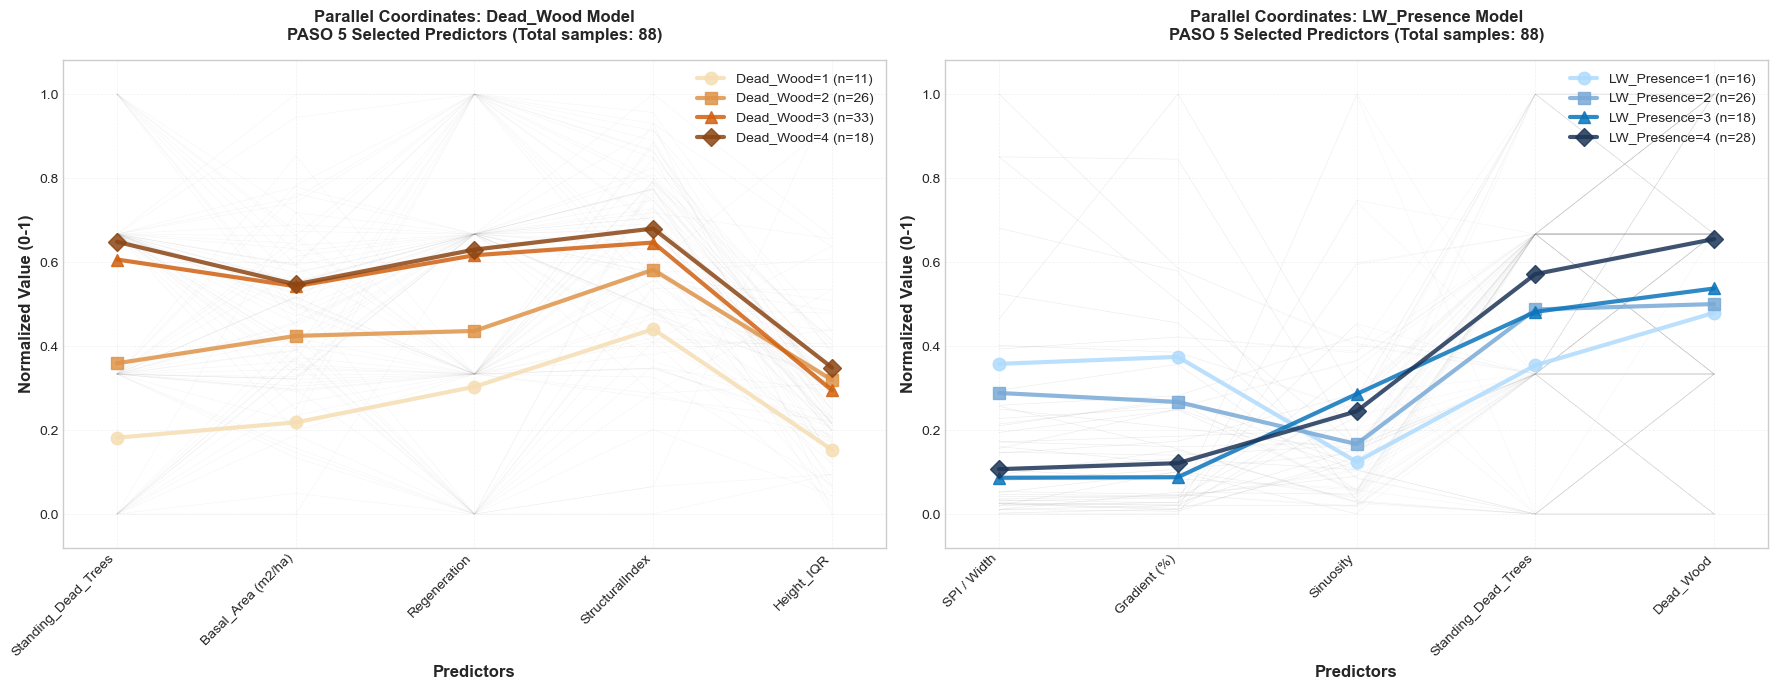


SUMMARY STATISTICS

✓ Dead_Wood Model:
  - Total samples: 88
  - Category distribution:
    → Dead_Wood=1:   11 samples ( 12.5%)
    → Dead_Wood=2:   26 samples ( 29.5%)
    → Dead_Wood=3:   33 samples ( 37.5%)
    → Dead_Wood=4:   18 samples ( 20.5%)

✓ LW_Presence Model:
  - Total samples: 88
  - Category distribution:
    → LW_Presence=1:   16 samples ( 18.2%)
    → LW_Presence=2:   26 samples ( 29.5%)
    → LW_Presence=3:   18 samples ( 20.5%)
    → LW_Presence=4:   28 samples ( 31.8%)

COLOR PALETTE INTERPRETATION

✓ Dead_Wood colors (Brown gradient - Understory structure intensity):
  - Category 1 (Wheat/Light):    #F5DEB3 - Low dead wood intensity
  - Category 2 (Peru):            #DE9348 - Medium-low dead wood intensity
  - Category 3 (Chocolate):       #D06111 - Medium-high dead wood intensity
  - Category 4 (Saddle brown):    #8B4513 - High dead wood intensity

✓ LW_Presence colors (Blue gradient - Channel energy/wood retention):
  - Category 1 (Very light blue): #AFDBFD - L

In [53]:
# Parallel Coordinates Plot - Custom Predictor Sets from PASO 5
# Using selected predictors from PASO 5 final decision logic with global color palettes

# Define custom feature sets based on PASO 5 selection
deadwood_features_custom = ['Standing_Dead_Trees', 'Basal_Area (m2/ha)', 'Regeneration', 'StructuralIndex', 'Height_IQR']
lw_features_custom = ['SPI / Width', 'Gradient (%)', 'Sinuosity', 'Standing_Dead_Trees', 'Dead_Wood']

print("=" * 110)
print("PARALLEL COORDINATES: PASO 5 Custom Predictor Sets")
print("=" * 110)
print(f"\n✓ Dead_Wood model predictors ({len(deadwood_features_custom)}):")
for i, feat in enumerate(deadwood_features_custom, 1):
    print(f"   {i}. {feat}")

print(f"\n✓ LW_Presence model predictors ({len(lw_features_custom)}):")
for i, feat in enumerate(lw_features_custom, 1):
    print(f"   {i}. {feat}")

# Prepare Dead_Wood data with custom features
print("\nPreparing data...")
prep_data_dw_custom = df_dead_wood[deadwood_features_custom + ['Dead_Wood_Category']].dropna()
scaler_dw_custom = MinMaxScaler()
prep_data_normalized_dw_custom = prep_data_dw_custom.copy()
prep_data_normalized_dw_custom[deadwood_features_custom] = scaler_dw_custom.fit_transform(prep_data_dw_custom[deadwood_features_custom])

# Prepare LW_Presence data with custom features
# Ensure LW_Presence_Category column exists (create if needed)
if 'LW_Presence_Category' not in df_lw.columns:
    df_lw['LW_Presence_Category'] = df_lw['LW_Presence'].astype(str)
prep_data_lw_custom = df_lw[lw_features_custom + ['LW_Presence_Category']].dropna()
scaler_lw_custom = MinMaxScaler()
prep_data_normalized_lw_custom = prep_data_lw_custom.copy()
prep_data_normalized_lw_custom[lw_features_custom] = scaler_lw_custom.fit_transform(prep_data_lw_custom[lw_features_custom])

# Create parallel coordinates plots with global color palettes
markers = {1: 'o', 2: 's', 3: '^', 4: 'D'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

data_sets_custom = [
    ('Dead_Wood', prep_data_normalized_dw_custom, 'Dead_Wood_Category', deadwood_features_custom, dw_class_colors),
    ('LW_Presence', prep_data_normalized_lw_custom, 'LW_Presence_Category', lw_features_custom, lw_class_colors)
]

for idx, (target_name, data, category_col, features, color_palette) in enumerate(data_sets_custom):
    ax = axes[idx]
    n_samples = len(data)
    
    # Plot individual samples (light gray lines) for context
    for _, row in data.iterrows():
        positions = np.arange(len(features))
        values = [row[feat] for feat in features]
        ax.plot(positions, values, alpha=0.08, color='gray', linewidth=0.4)
    
    # Plot mean profiles (thick colored lines) by category using global color palettes
    for category in sorted(data[category_col].unique()):
        subset = data[data[category_col] == category]
        positions = np.arange(len(features))
        mean_values = [subset[feat].mean() for feat in features]
        cat_int = int(category)
        ax.plot(positions, mean_values, linewidth=3, marker=markers[cat_int], 
               label=f'{target_name}={cat_int} (n={len(subset)})', markersize=9, 
               alpha=0.85, color=color_palette[cat_int])
    
    # Formatting
    ax.set_xlabel('Predictors', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
    ax.set_title(f'Parallel Coordinates: {target_name} Model\nPASO 5 Selected Predictors (Total samples: {n_samples})', 
                fontsize=12, fontweight='bold', pad=15)
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=10, loc='upper right', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_ylim(-0.08, 1.08)
    ax.set_xlim(-0.3, len(features)-0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 110)
print("SUMMARY STATISTICS")
print("=" * 110)

print(f"\n✓ Dead_Wood Model:")
print(f"  - Total samples: {len(prep_data_normalized_dw_custom)}")
print(f"  - Category distribution:")
for cat in sorted(prep_data_dw_custom['Dead_Wood_Category'].unique()):
    count = len(prep_data_dw_custom[prep_data_dw_custom['Dead_Wood_Category'] == cat])
    pct = 100 * count / len(prep_data_dw_custom)
    print(f"    → Dead_Wood={int(cat)}: {count:4d} samples ({pct:5.1f}%)")

print(f"\n✓ LW_Presence Model:")
print(f"  - Total samples: {len(prep_data_normalized_lw_custom)}")
print(f"  - Category distribution:")
for cat in sorted(prep_data_lw_custom['LW_Presence_Category'].unique()):
    count = len(prep_data_lw_custom[prep_data_lw_custom['LW_Presence_Category'] == cat])
    pct = 100 * count / len(prep_data_lw_custom)
    print(f"    → LW_Presence={int(cat)}: {count:4d} samples ({pct:5.1f}%)")

print("\n" + "=" * 110)
print("COLOR PALETTE INTERPRETATION")
print("=" * 110)
print(f"""
✓ Dead_Wood colors (Brown gradient - Understory structure intensity):
  - Category 1 (Wheat/Light):    {dw_class_colors[1]} - Low dead wood intensity
  - Category 2 (Peru):            {dw_class_colors[2]} - Medium-low dead wood intensity
  - Category 3 (Chocolate):       {dw_class_colors[3]} - Medium-high dead wood intensity
  - Category 4 (Saddle brown):    {dw_class_colors[4]} - High dead wood intensity

✓ LW_Presence colors (Blue gradient - Channel energy/wood retention):
  - Category 1 (Very light blue): {lw_class_colors[1]} - Low LW presence
  - Category 2 (Medium blue):     {lw_class_colors[2]} - Medium-low LW presence
  - Category 3 (Dark blue):       {lw_class_colors[3]} - Medium-high LW presence
  - Category 4 (Deep blue):       {lw_class_colors[4]} - High LW presence (channel energy-controlled)

Marker symbols by category:
  → Circle (o) = Category 1
  → Square (s) = Category 2  
  → Triangle (^) = Category 3
  → Diamond (D) = Category 4

Key insights from parallel coordinates:
  • Parallel lines across features = strong intercorrelation
  • Diverging lines = predictor differentiates the response category
  • Clustering of lines = homogeneous predictor patterns within categories
  • High variability in individual lines = high within-category heterogeneity
""")

In [54]:
# ==================== DATA PREPARATION FOR VISUALIZATIONS ====================
# Create filtered dataframes and category columns for Dead_Wood and LW_Presence

print("=" * 110)
print("DATA PREPARATION: Creating filtered datasets and category columns")
print("=" * 110)

# Import MinMaxScaler for normalization
from sklearn.preprocessing import MinMaxScaler

# Create Dead_Wood dataset with valid values (1, 2, 3, 4)
df_dead_wood = df[df['Dead_Wood'].isin([1, 2, 3, 4])].copy()
df_dead_wood['Dead_Wood_Category'] = df_dead_wood['Dead_Wood'].astype(str)

print(f"\n✓ Dead_Wood dataset:")
print(f"  - Samples: {len(df_dead_wood)}")
print(f"  - Category distribution:")
for cat in sorted(df_dead_wood['Dead_Wood'].unique()):
    count = len(df_dead_wood[df_dead_wood['Dead_Wood'] == cat])
    pct = 100 * count / len(df_dead_wood)
    print(f"    → Category {int(cat)}: {count:4d} samples ({pct:5.1f}%)")

# Create LW_Presence dataset with valid values (1, 2, 3, 4)
df_lw = df[df['LW_Presence'].isin([1, 2, 3, 4])].copy()
df_lw['LW_Presence_Category'] = df_lw['LW_Presence'].astype(str)

print(f"\n✓ LW_Presence dataset:")
print(f"  - Samples: {len(df_lw)}")
print(f"  - Category distribution:")
for cat in sorted(df_lw['LW_Presence'].unique()):
    count = len(df_lw[df_lw['LW_Presence'] == cat])
    pct = 100 * count / len(df_lw)
    print(f"    → Category {int(cat)}: {count:4d} samples ({pct:5.1f}%)")

print(f"\n✓ Data preparation complete. Ready for visualization.")

DATA PREPARATION: Creating filtered datasets and category columns

✓ Dead_Wood dataset:
  - Samples: 88
  - Category distribution:
    → Category 1:   11 samples ( 12.5%)
    → Category 2:   26 samples ( 29.5%)
    → Category 3:   33 samples ( 37.5%)
    → Category 4:   18 samples ( 20.5%)

✓ LW_Presence dataset:
  - Samples: 88
  - Category distribution:
    → Category 1:   16 samples ( 18.2%)
    → Category 2:   26 samples ( 29.5%)
    → Category 3:   18 samples ( 20.5%)
    → Category 4:   28 samples ( 31.8%)

✓ Data preparation complete. Ready for visualization.


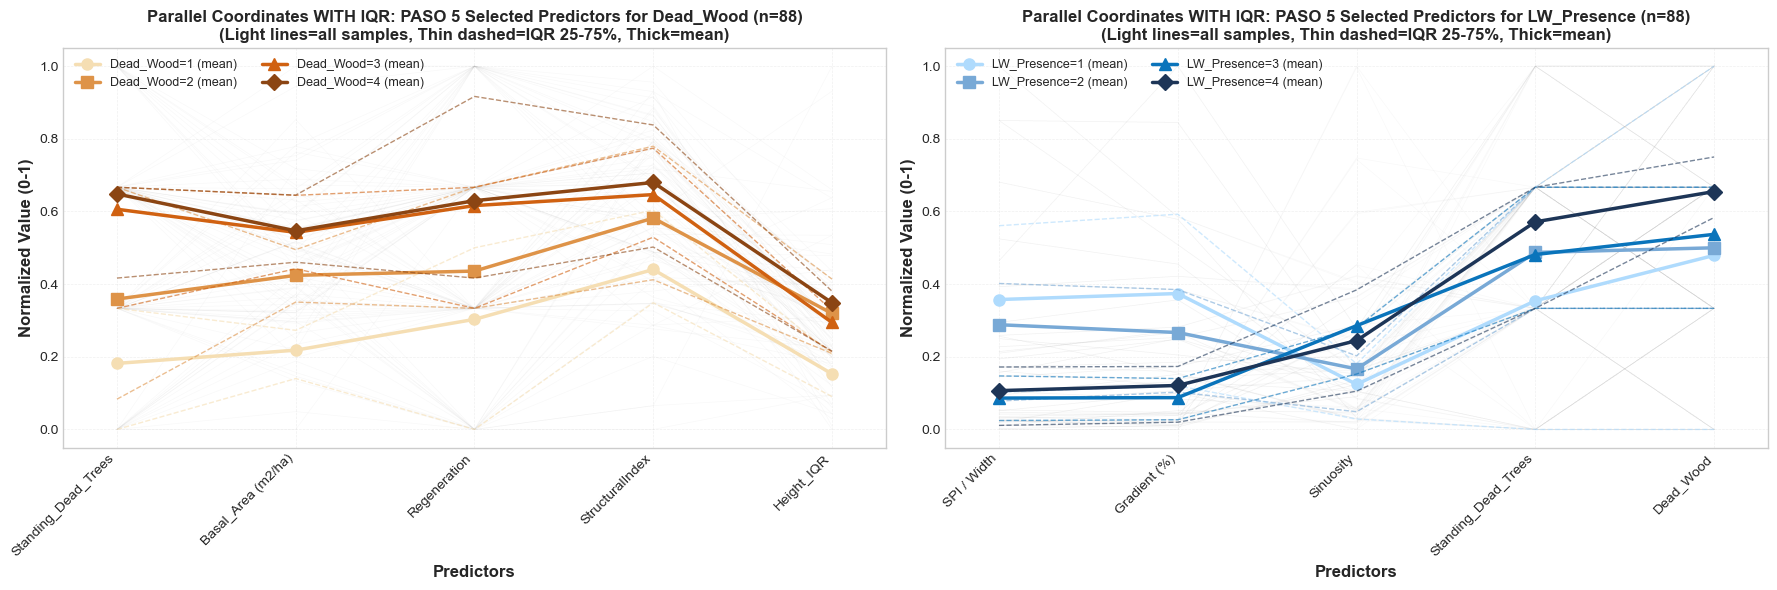


PARALLEL COORDINATES WITH IQR - PASO 5 CUSTOM PREDICTORS

Visualization Components:
  • Light gray lines: Individual observations (all samples)
  • Thin dashed lines: 25th and 75th percentile bounds (Interquartile Range)
  • Thick colored lines: Mean profiles for each category
  
Marker Symbols by Category:
  → Circle (o) = Category 1
  → Square (s) = Category 2
  → Triangle (^) = Category 3
  → Diamond (D) = Category 4

Color Interpretations:
  Dead_Wood (Brown gradient):
    • Light brown (#F5DEB3) = Category 1 (Low dead wood)
    • Medium browns (#DE9348 → #D06111) = Categories 2-3
    • Dark brown (#8B4513) = Category 4 (High dead wood)
  
  LW_Presence (Blue gradient):
    • Light blue (#AFDBFD) = Category 1 (Low LW presence)
    • Medium/dark blues (#78A9D6 → #0A74BB) = Categories 2-3
    • Deep blue (#1D3557) = Category 4 (High LW presence)

Key Insights from Parallel Coordinates:
  • Parallel lines across features = strong predictor intercorrelation
  • Diverging lines = predi

In [55]:
# Parallel Coordinates Plot WITH IQR BANDS - Custom PASO 5 Predictors
# Same as above but includes IQR (25-75%) as thin lines in same color as mean using global palettes

markers = {1: 'o', 2: 's', 3: '^', 4: 'D'}
# Use global color palettes defined at the beginning
colors_dw = dw_class_colors
colors_lw = lw_class_colors

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

data_sets = [
    ('Dead_Wood', prep_data_normalized_dw_custom, 'Dead_Wood_Category', deadwood_features_custom, colors_dw),
    ('LW_Presence', prep_data_normalized_lw_custom, 'LW_Presence_Category', lw_features_custom, colors_lw)
]

for idx, (target_name, data, category_col, features, colors_palette) in enumerate(data_sets):
    ax = axes[idx]
    n_samples = len(data)
    
    # Plot individual samples (light lines)
    for _, row in data.iterrows():
        positions = np.arange(len(features))
        values = [row[feat] for feat in features]
        ax.plot(positions, values, alpha=0.05, color='gray', linewidth=0.5)
    
    # Plot mean profiles with IQR thin lines
    for category in sorted(data[category_col].unique()):
        subset = data[data[category_col] == category]
        positions = np.arange(len(features))
        
        # Calculate mean and IQR for each feature
        mean_values = []
        q25_values = []
        q75_values = []
        
        for feat in features:
            mean_values.append(subset[feat].mean())
            q25_values.append(subset[feat].quantile(0.25))
            q75_values.append(subset[feat].quantile(0.75))
        
        cat_int = int(category)
        cat_color = colors_palette[cat_int]
        
        # Plot Q25 and Q75 as thin lines with same color as mean
        ax.plot(positions, q25_values, linewidth=1, color=cat_color, alpha=0.6, linestyle='--')
        ax.plot(positions, q75_values, linewidth=1, color=cat_color, alpha=0.6, linestyle='--')
        
        # Plot mean line on top with distinct marker per category
        ax.plot(positions, mean_values, linewidth=2.5, marker=markers[cat_int], 
                label=f'{target_name}={cat_int} (mean)', markersize=8, color=cat_color)
    
    ax.set_xlabel('Predictors', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
    ax.set_title(f'Parallel Coordinates WITH IQR: PASO 5 Selected Predictors for {target_name} (n={n_samples})\n(Light lines=all samples, Thin dashed=IQR 25-75%, Thick=mean)', 
                fontsize=12, fontweight='bold')
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.3, len(features)-0.7)

plt.tight_layout()
plt.show()

print("\n" + "=" * 110)
print("PARALLEL COORDINATES WITH IQR - PASO 5 CUSTOM PREDICTORS")
print("=" * 110)
print("""
Visualization Components:
  • Light gray lines: Individual observations (all samples)
  • Thin dashed lines: 25th and 75th percentile bounds (Interquartile Range)
  • Thick colored lines: Mean profiles for each category
  
Marker Symbols by Category:
  → Circle (o) = Category 1
  → Square (s) = Category 2
  → Triangle (^) = Category 3
  → Diamond (D) = Category 4

Color Interpretations:
  Dead_Wood (Brown gradient):
    • Light brown (#F5DEB3) = Category 1 (Low dead wood)
    • Medium browns (#DE9348 → #D06111) = Categories 2-3
    • Dark brown (#8B4513) = Category 4 (High dead wood)
  
  LW_Presence (Blue gradient):
    • Light blue (#AFDBFD) = Category 1 (Low LW presence)
    • Medium/dark blues (#78A9D6 → #0A74BB) = Categories 2-3
    • Deep blue (#1D3557) = Category 4 (High LW presence)

Key Insights from Parallel Coordinates:
  • Parallel lines across features = strong predictor intercorrelation
  • Diverging lines = predictor differentiates the response category well
  • Convergence of lines = predictor has low discriminative power
  • Tight IQR bounds = homogeneous category patterns (low within-category variability)
  • Wide IQR bounds = heterogeneous patterns (high within-category variability)
""")

MEAN VALUES BY REACH AND BANK (RipUnit-level aggregation)
Reach   Bank  StructuralIndex  Basal_Area (m2/ha)  n_ripunits
 A-A1  Left          0.873293            26.88376           1
 A-A1 Right          0.850755            45.93959           1
A-A10  Left          0.723197            31.86217           1
A-A10 Right          0.638214            29.21011           1
A-A11  Left          0.730115            32.19464           1
A-A11 Right          0.710310            23.17380           1
A-A12  Left          0.776058            45.14998           1
A-A12 Right          0.768696            40.19631           1
A-A13  Left          0.885547            24.14588           1
A-A13 Right          0.855317            30.99941           1
A-A14 Right          0.869207            23.47200           1
A-A14  Left          0.852535            24.57593           1
A-A15  Left          0.875221            20.41301           1
A-A15 Right          0.707050            23.67670           1
A-A16  Left 

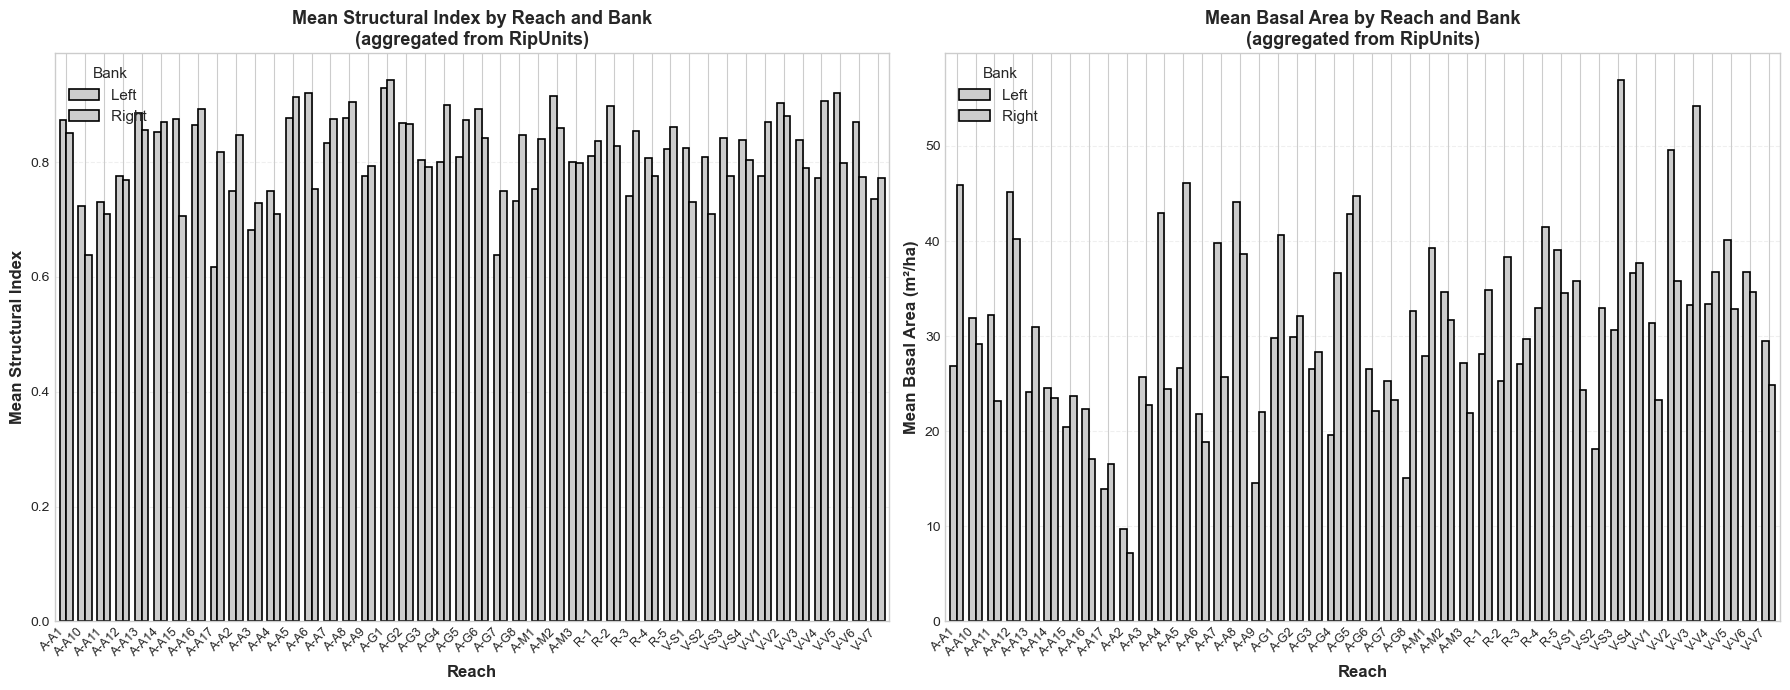


✓ Figure saved to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1 (VariablesSubBasin\figures\StructuralIndex_BasalArea_by_Reach_Bank.png

SUMMARY TABLE FOR EXPORT
Reach   Bank  Structural Index (Mean)  Basal Area m2/ha (Mean)  RipUnit Count
 A-A1  Left                  0.873293                 26.88376              1
 A-A1 Right                  0.850755                 45.93959              1
A-A10  Left                  0.723197                 31.86217              1
A-A10 Right                  0.638214                 29.21011              1
A-A11  Left                  0.730115                 32.19464              1
A-A11 Right                  0.710310                 23.17380              1
A-A12  Left                  0.776058                 45.14998              1
A-A12 Right                  0.768696                 40.19631              1
A-A13  Left                  0.885547                 24.14588              1


<Figure size 640x480 with 0 Axes>

In [56]:
# Mean Structural Index and Basal Area by Reach and Bank
# Two rows for each Reach showing Left vs Right Bank comparison

# Step 1: Aggregate to RipUnit level (in case multiple rows per RipUnit)
ripunit_stats = df.groupby(['Id_RipUnit', 'Reach', 'Bank']).agg({
    'StructuralIndex': 'mean',
    'Basal_Area (m2/ha)': 'mean'
}).reset_index()

# Step 2: Calculate statistics by Reach and Bank (using RipUnit-level means)
reach_bank_stats = ripunit_stats.groupby(['Reach', 'Bank']).agg({
    'StructuralIndex': 'mean',
    'Basal_Area (m2/ha)': 'mean',
    'Id_RipUnit': 'count'  # Count RipUnits (not individual rows)
}).reset_index()
reach_bank_stats.rename(columns={'Id_RipUnit': 'n_ripunits'}, inplace=True)
reach_bank_stats = reach_bank_stats.sort_values('Reach').reset_index(drop=True)

print("="*100)
print("MEAN VALUES BY REACH AND BANK (RipUnit-level aggregation)")
print("="*100)
print(reach_bank_stats.to_string(index=False))

# Create pivot tables for easier plotting
pivot_structural = reach_bank_stats.pivot(index='Reach', columns='Bank', values='StructuralIndex')
pivot_basal = reach_bank_stats.pivot(index='Reach', columns='Bank', values='Basal_Area (m2/ha)')

# Create figure with cleaner, simpler bar plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define colors
colors = {'Left': '#1f77b4', 'Right': '#ff7f0e'}

# Plot 1: Structural Index
ax1 = axes[0]
pivot_structural.plot(kind='bar', ax=ax1, color=[colors.get(bank, '#cccccc') for bank in pivot_structural.columns],
                      width=0.7, edgecolor='black', linewidth=1.2)
ax1.set_title('Mean Structural Index by Reach and Bank\n(aggregated from RipUnits)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Reach', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Structural Index', fontsize=12, fontweight='bold')
ax1.legend(title='Bank', fontsize=11, title_fontsize=11, loc='upper left')
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9)
for label in ax1.get_xticklabels():
    label.set_rotation(45)

# Plot 2: Basal Area
ax2 = axes[1]
pivot_basal.plot(kind='bar', ax=ax2, color=[colors.get(bank, '#cccccc') for bank in pivot_basal.columns],
                 width=0.7, edgecolor='black', linewidth=1.2)
ax2.set_title('Mean Basal Area by Reach and Bank\n(aggregated from RipUnits)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Reach', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Basal Area (m²/ha)', fontsize=12, fontweight='bold')
ax2.legend(title='Bank', fontsize=11, title_fontsize=11, loc='upper left')
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
for label in ax2.get_xticklabels():
    label.set_rotation(45)

plt.tight_layout()
plt.show()

# Save the figure
output_file = get_output_path('StructuralIndex_BasalArea_by_Reach_Bank.png', subfolder='figures')
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Figure saved to: {output_file}")

# Create summary table for export
summary_table = reach_bank_stats[['Reach', 'Bank', 'StructuralIndex', 'Basal_Area (m2/ha)', 'n_ripunits']].copy()
summary_table.columns = ['Reach', 'Bank', 'Structural Index (Mean)', 'Basal Area m2/ha (Mean)', 'RipUnit Count']

print("\n" + "="*100)
print("SUMMARY TABLE FOR EXPORT")
print("="*100)
print(summary_table.to_string(index=False))

# Save summary table as CSV
csv_file = get_output_path('StructuralIndex_BasalArea_by_Reach_Bank.csv')
summary_table.to_csv(csv_file, index=False)
print(f"\n✓ Summary table saved to: {csv_file}")

print(f"\n✓ COMPLETED: Structural Index and Basal Area aggregated by Reach and Bank")

In [57]:
# Debug: Simpler check
print(f"Reach-Bank stats shape: {reach_bank_stats.shape}")
print(f"Unique reaches: {reach_bank_stats['Reach'].nunique()}")
print(f"Unique banks: {reach_bank_stats['Bank'].nunique()}")

print(f"\nStructuralIndex column - min: {reach_bank_stats['StructuralIndex'].min():.6f}, max: {reach_bank_stats['StructuralIndex'].max():.6f}")
print(f"Basal_Area column - min: {reach_bank_stats['Basal_Area (m2/ha)'].min():.6f}, max: {reach_bank_stats['Basal_Area (m2/ha)'].max():.6f}")

print(f"\nFirst 10 rows of reach_bank_stats:")
print(reach_bank_stats.head(10).to_string(index=False))

Reach-Bank stats shape: (88, 5)
Unique reaches: 44
Unique banks: 2

StructuralIndex column - min: 0.616880, max: 0.942811
Basal_Area column - min: 7.244000, max: 56.910150

First 10 rows of reach_bank_stats:
Reach   Bank  StructuralIndex  Basal_Area (m2/ha)  n_ripunits
 A-A1  Left          0.873293            26.88376           1
 A-A1 Right          0.850755            45.93959           1
A-A10  Left          0.723197            31.86217           1
A-A10 Right          0.638214            29.21011           1
A-A11  Left          0.730115            32.19464           1
A-A11 Right          0.710310            23.17380           1
A-A12  Left          0.776058            45.14998           1
A-A12 Right          0.768696            40.19631           1
A-A13  Left          0.885547            24.14588           1
A-A13 Right          0.855317            30.99941           1


In [58]:
# Percentiles (P25, P50, P75) by Sub_Basin for Structural Index and Basal Area

print("="*120)
print("PERCENTILE ANALYSIS BY SUB_BASIN")
print("="*120)

# Calculate percentiles for Structural Index by Sub_Basin
print("\n✓ Structural Index - Percentiles by Sub_Basin:")
structural_percentiles = df.groupby('Sub_Basin')['StructuralIndex'].quantile([0.25, 0.50, 0.75]).unstack()
structural_percentiles.columns = ['P25', 'P50', 'P75']
structural_percentiles = structural_percentiles.reset_index()

print(structural_percentiles.to_string(index=False))

# Calculate percentiles for Basal Area by Sub_Basin
print("\n✓ Basal Area (m²/ha) - Percentiles by Sub_Basin:")
basal_percentiles = df.groupby('Sub_Basin')['Basal_Area (m2/ha)'].quantile([0.25, 0.50, 0.75]).unstack()
basal_percentiles.columns = ['P25', 'P50', 'P75']
basal_percentiles = basal_percentiles.reset_index()

print(basal_percentiles.to_string(index=False))

# Create a combined summary table
print("\n" + "="*120)
print("COMBINED SUMMARY TABLE")
print("="*120)

# Merge the two tables
combined_percentiles = structural_percentiles.merge(basal_percentiles, on='Sub_Basin', suffixes=('_StructuralIndex', '_BasalArea'))
# Reorder columns for better readability
combined_percentiles = combined_percentiles[['Sub_Basin', 
                                              'P25_StructuralIndex', 'P50_StructuralIndex', 'P75_StructuralIndex',
                                              'P25_BasalArea', 'P50_BasalArea', 'P75_BasalArea']]

# Rename columns for clarity
combined_percentiles.columns = ['Sub_Basin', 
                                'SI_P25', 'SI_P50', 'SI_P75',
                                'BA_P25', 'BA_P50', 'BA_P75']

print(combined_percentiles.to_string(index=False))

# Export to CSV
csv_file_structural = get_output_path('Percentiles_StructuralIndex_by_SubBasin.csv')
csv_file_basal = get_output_path('Percentiles_BasalArea_by_SubBasin.csv')
csv_file_combined = get_output_path('Percentiles_Combined_by_SubBasin.csv')

structural_percentiles.to_csv(csv_file_structural, index=False)
basal_percentiles.to_csv(csv_file_basal, index=False)
combined_percentiles.to_csv(csv_file_combined, index=False)

print(f"\n✓ Exported to:")
print(f"  - {csv_file_structural.name}")
print(f"  - {csv_file_basal.name}")
print(f"  - {csv_file_combined.name}")

# Display sample count per Sub_Basin for context
print("\n" + "="*120)
print("SAMPLE COUNT PER SUB_BASIN")
print("="*120)

sample_counts = df.groupby('Sub_Basin').size().reset_index(name='Total_Samples')
structural_valid = df.groupby('Sub_Basin')['StructuralIndex'].count().reset_index(name='StructuralIndex_Valid')
basal_valid = df.groupby('Sub_Basin')['Basal_Area (m2/ha)'].count().reset_index(name='BasalArea_Valid')

sample_summary = sample_counts.merge(structural_valid, on='Sub_Basin').merge(basal_valid, on='Sub_Basin')
print(sample_summary.to_string(index=False))

print(f"\n✓ PERCENTILE ANALYSIS COMPLETED")

PERCENTILE ANALYSIS BY SUB_BASIN

✓ Structural Index - Percentiles by Sub_Basin:
Sub_Basin      P25      P50      P75
     Arve 0.735192 0.825793 0.874573
   Giffre 0.798674 0.844798 0.878272
   Menoge 0.798470 0.820298 0.855111
    Rhone 0.808019 0.824994 0.849596
   Semine 0.764504 0.807048 0.828503
Valserine 0.774903 0.818060 0.877709

✓ Basal Area (m²/ha) - Percentiles by Sub_Basin:
Sub_Basin       P25       P50       P75
     Arve 21.814865 24.513675 32.111522
   Giffre 24.789793 29.076990 33.630758
   Menoge 27.384853 29.787780 33.918925
    Rhone 28.479882 33.739995 37.455385
   Semine 29.104177 34.336435 36.948023
Valserine 31.750150 33.983330 36.768190

COMBINED SUMMARY TABLE
Sub_Basin   SI_P25   SI_P50   SI_P75    BA_P25    BA_P50    BA_P75
     Arve 0.735192 0.825793 0.874573 21.814865 24.513675 32.111522
   Giffre 0.798674 0.844798 0.878272 24.789793 29.076990 33.630758
   Menoge 0.798470 0.820298 0.855111 27.384853 29.787780 33.918925
    Rhone 0.808019 0.824994 0.849596 2

PERCENTILE BAR GRAPHS WITH ERROR BARS (P25-P75 around P50) BY SUB_BASIN


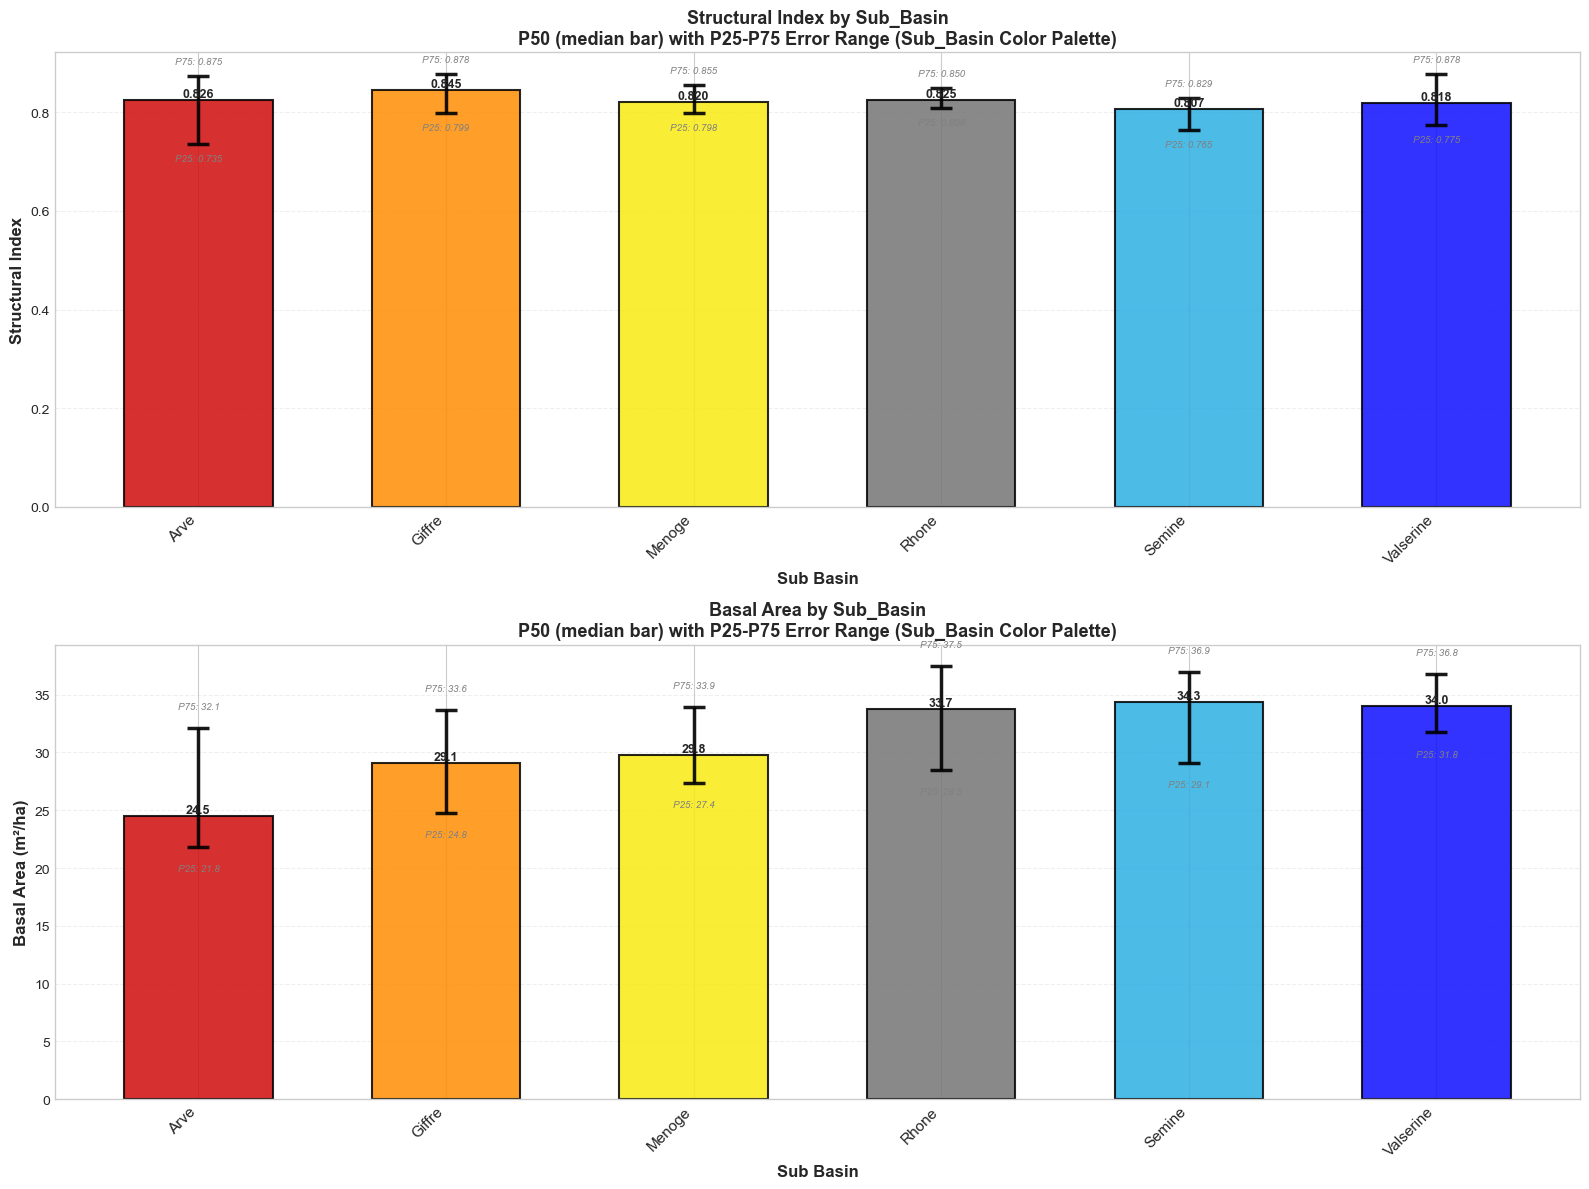


✓ Figure saved to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1 (VariablesSubBasin\figures\Percentiles_BarGraphs_ErrorBars_by_SubBasin.png

ERROR BAR INTERPRETATION - SUB_BASIN COLOR PALETTE

Bar Height = P50 (Median - 50th percentile):
  • Represents the central tendency of each Sub_Basin
  
Error Bar Range = P25 to P75 (Interquartile Range):
  • Lower bound = P25 (25th percentile) - represents lowest 25% of values
  • Upper bound = P75 (75th percentile) - represents highest 25% of values
  • Shows the middle 50% of the data distribution

Sub_Basin Color Scheme:
  • Arve: #D10C0CC5 (Red)
  • Giffre: #FF8E03BA (Orange)
  • Menoge: #FAEA12CE (Yellow)
  • Rhone: #757575BA (Gray)
  • Semine: #2DAFE2C1 (Light Blue)
  • Valserine: #0F0FFFB2 (Blue)

Insight:
  • Longer error bars = greater variability within Sub_Basin (heterogeneous conditions)
  • Shorter error bars = less variability within Sub_Basin (homogeneous conditions)
  • Ea

<Figure size 640x480 with 0 Axes>

In [59]:
# Bar Graphs: P50 (median) with P25-P75 as error bars by Sub_Basin - Using Sub_Basin Color Palette

print("="*120)
print("PERCENTILE BAR GRAPHS WITH ERROR BARS (P25-P75 around P50) BY SUB_BASIN")
print("="*120)

# Define color palette for Sub_Basin (used consistently across all graphics)
subbasin_colors = {
    'Arve': "#D10C0CC5",          # Red
    'Giffre': "#FF8E03BA",        # Orange
    'Menoge': "#FAEA12CE",        # Yellow
    'Rhone': "#757575BA",         # Gray
    'Semine': "#2DAFE2C1",        # Light Blue
    'Valserine': "#0F0FFFB2"      # Blue
}

# Sort sub-basins for consistent visualization
subbasins_sorted = sorted(structural_percentiles['Sub_Basin'].unique())

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ==================== PLOT 1: Structural Index ====================
ax1 = axes[0]

x_pos = np.arange(len(subbasins_sorted))
width = 0.6

# Prepare data for Structural Index
si_p25 = []
si_p50 = []
si_p75 = []
colors_list = []

for subbasin in subbasins_sorted:
    row = structural_percentiles[structural_percentiles['Sub_Basin'] == subbasin]
    si_p25.append(row['P25'].values[0] if len(row) > 0 else np.nan)
    si_p50.append(row['P50'].values[0] if len(row) > 0 else np.nan)
    si_p75.append(row['P75'].values[0] if len(row) > 0 else np.nan)
    colors_list.append(subbasin_colors.get(subbasin, '#cccccc'))

# Convert to numpy arrays for error calculation
si_p25 = np.array(si_p25)
si_p50 = np.array(si_p50)
si_p75 = np.array(si_p75)

# Calculate error bars: lower = P50 - P25, upper = P75 - P50
si_err_lower = si_p50 - si_p25
si_err_upper = si_p75 - si_p50

# Plot bars with error bars using Sub_Basin palette
for i, (x, height, color) in enumerate(zip(x_pos, si_p50, colors_list)):
    if not np.isnan(height):
        ax1.bar(x, height, width, color=color, alpha=0.85, edgecolor='black', linewidth=1.5,
               yerr=[[si_err_lower[i]], [si_err_upper[i]]], capsize=8,
               error_kw={'elinewidth': 2.5, 'capthick': 2.5, 'alpha': 0.9, 'color': 'black'})
        
        # Add value labels on bars
        ax1.text(x, height, f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        # Add percentile labels near error bars
        ax1.text(x, height - si_err_lower[i] - 0.02, f'P25: {si_p25[i]:.3f}', 
                ha='center', va='top', fontsize=7, style='italic', color='gray')
        ax1.text(x, height + si_err_upper[i] + 0.02, f'P75: {si_p75[i]:.3f}', 
                ha='center', va='bottom', fontsize=7, style='italic', color='gray')

ax1.set_xlabel('Sub Basin', fontsize=12, fontweight='bold')
ax1.set_ylabel('Structural Index', fontsize=12, fontweight='bold')
ax1.set_title('Structural Index by Sub_Basin\nP50 (median bar) with P25-P75 Error Range (Sub_Basin Color Palette)', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(subbasins_sorted, rotation=45, ha='right', fontsize=11)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

# ==================== PLOT 2: Basal Area ====================
ax2 = axes[1]

# Prepare data for Basal Area
ba_p25 = []
ba_p50 = []
ba_p75 = []

for subbasin in subbasins_sorted:
    row = basal_percentiles[basal_percentiles['Sub_Basin'] == subbasin]
    ba_p25.append(row['P25'].values[0] if len(row) > 0 else np.nan)
    ba_p50.append(row['P50'].values[0] if len(row) > 0 else np.nan)
    ba_p75.append(row['P75'].values[0] if len(row) > 0 else np.nan)

# Convert to numpy arrays for error calculation
ba_p25 = np.array(ba_p25)
ba_p50 = np.array(ba_p50)
ba_p75 = np.array(ba_p75)

# Calculate error bars: lower = P50 - P25, upper = P75 - P50
ba_err_lower = ba_p50 - ba_p25
ba_err_upper = ba_p75 - ba_p50

# Plot bars with error bars using Sub_Basin palette
for i, (x, height, color) in enumerate(zip(x_pos, ba_p50, colors_list)):
    if not np.isnan(height):
        ax2.bar(x, height, width, color=color, alpha=0.85, edgecolor='black', linewidth=1.5,
               yerr=[[ba_err_lower[i]], [ba_err_upper[i]]], capsize=8,
               error_kw={'elinewidth': 2.5, 'capthick': 2.5, 'alpha': 0.9, 'color': 'black'})
        
        # Add value labels on bars
        ax2.text(x, height, f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        # Add percentile labels near error bars
        ax2.text(x, height - ba_err_lower[i] - 1.5, f'P25: {ba_p25[i]:.1f}', 
                ha='center', va='top', fontsize=7, style='italic', color='gray')
        ax2.text(x, height + ba_err_upper[i] + 1.5, f'P75: {ba_p75[i]:.1f}', 
                ha='center', va='bottom', fontsize=7, style='italic', color='gray')

ax2.set_xlabel('Sub Basin', fontsize=12, fontweight='bold')
ax2.set_ylabel('Basal Area (m²/ha)', fontsize=12, fontweight='bold')
ax2.set_title('Basal Area by Sub_Basin\nP50 (median bar) with P25-P75 Error Range (Sub_Basin Color Palette)', 
              fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(subbasins_sorted, rotation=45, ha='right', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Save figure
output_fig = get_output_path('Percentiles_BarGraphs_ErrorBars_by_SubBasin.png', subfolder='figures')
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
print(f"\n✓ Figure saved to: {output_fig}")

# Print interpretation
print("\n" + "="*120)
print("ERROR BAR INTERPRETATION - SUB_BASIN COLOR PALETTE")
print("="*120)
print(f"""
Bar Height = P50 (Median - 50th percentile):
  • Represents the central tendency of each Sub_Basin
  
Error Bar Range = P25 to P75 (Interquartile Range):
  • Lower bound = P25 (25th percentile) - represents lowest 25% of values
  • Upper bound = P75 (75th percentile) - represents highest 25% of values
  • Shows the middle 50% of the data distribution

Sub_Basin Color Scheme:
  • Arve: #D10C0CC5 (Red)
  • Giffre: #FF8E03BA (Orange)
  • Menoge: #FAEA12CE (Yellow)
  • Rhone: #757575BA (Gray)
  • Semine: #2DAFE2C1 (Light Blue)
  • Valserine: #0F0FFFB2 (Blue)

Insight:
  • Longer error bars = greater variability within Sub_Basin (heterogeneous conditions)
  • Shorter error bars = less variability within Sub_Basin (homogeneous conditions)
  • Each Sub_Basin has unique colors for consistent identification across all visualizations
""")

print(f"\n✓ PERCENTILE BAR GRAPHS WITH SUB_BASIN COLOR PALETTE COMPLETED")


SIMPLIFIED HEATMAP: Comparative Riparian Wood and Forest Profiles by Sub-Basin


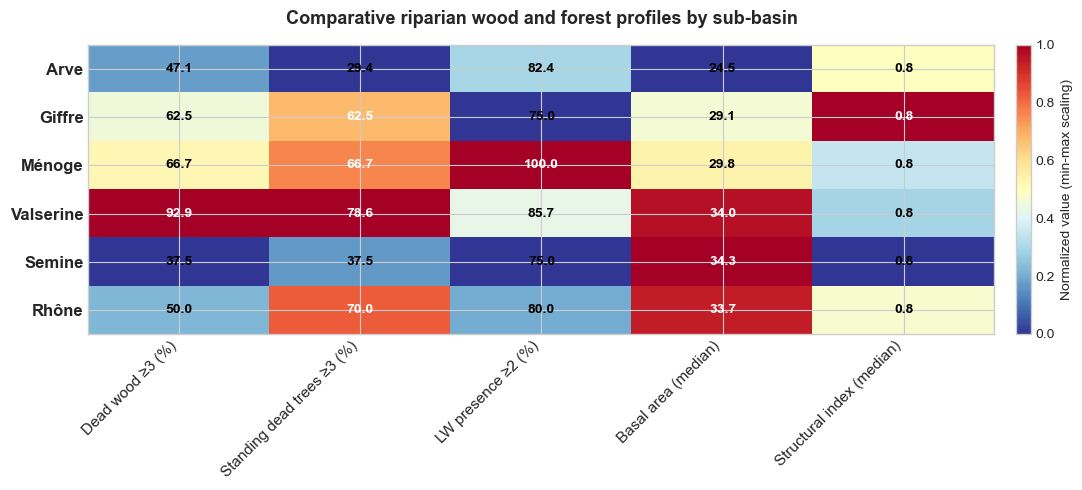


✓ Simplified heatmap created and saved
✓ Variables included: 5
✓ Sub-basins ordered: Arve > Giffre > Ménoge > Valserine > Semine > Rhône



In [60]:
# ============================================================================
# SIMPLIFIED HEATMAP: RIPARIAN WOOD AND FOREST PROFILES
# Focus on key variables for comparative analysis
# ============================================================================

print("\n" + "="*140)
print("SIMPLIFIED HEATMAP: Comparative Riparian Wood and Forest Profiles by Sub-Basin")
print("="*140)

# Define exact subbasin order as requested
subbasin_order_final = ['Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine', 'Rhone']

# Select only the 5 key variables
heatmap_cols_simplified = [
    'Dead_Wood_%>=3',
    'Standing_Dead_Trees_%>=3',
    'LW_Presence_%>=2',
    'Basal_Area_median',
    'StructuralIndex_median'
]

heatmap_labels_simplified = [
    'Dead wood ≥3 (%)',
    'Standing dead trees ≥3 (%)',
    'LW presence ≥2 (%)',
    'Basal area (median)',
    'Structural index (median)'
]

# Build dataframe with correct subbasin order
df_heatmap_simplified = df_synthetic.set_index('Sub_Basin')[heatmap_cols_simplified].copy()

# Reorder to match requested sequence
df_heatmap_simplified = df_heatmap_simplified.reindex(subbasin_order_final)

# Normalize by column (min-max scaling)
df_heatmap_simplified_norm = pd.DataFrame(
    index=df_heatmap_simplified.index,
    columns=df_heatmap_simplified.columns
)
for col in heatmap_cols_simplified:
    df_heatmap_simplified_norm[col] = robust_minmax_normalize(df_heatmap_simplified[col])

# Create figure with cleaner style
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(df_heatmap_simplified_norm.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(heatmap_cols_simplified)))
ax.set_yticks(np.arange(len(subbasin_order_final)))
ax.set_xticklabels(heatmap_labels_simplified, fontsize=11, rotation=45, ha='right')
ax.set_yticklabels([get_preferred_display_name(sb) for sb in subbasin_order_final], 
                    fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Normalized value (min-max scaling)', pad=0.02)
cbar.ax.tick_params(labelsize=10)

# Add real values inside cells
for i in range(len(subbasin_order_final)):
    for j in range(len(heatmap_cols_simplified)):
        val = df_heatmap_simplified.iloc[i, j]
        norm_val = df_heatmap_simplified_norm.iloc[i, j]
        
        if pd.isna(val):
            text_str = 'NA'
            color_text = 'gray'
        else:
            text_str = f'{val:.1f}'
            color_text = 'white' if norm_val > 0.6 else 'black'
        
        ax.text(j, i, text_str, ha='center', va='center',
               color=color_text, fontsize=10, fontweight='bold')

# Title and layout
ax.set_title('Comparative riparian wood and forest profiles by sub-basin',
            fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

# Save figure
plt.savefig(get_output_path('03_Simplified_Heatmap_WoodForestProfiles.png', subfolder='figures'),
           dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n✓ Simplified heatmap created and saved")
print(f"✓ Variables included: {len(heatmap_cols_simplified)}")
print(f"✓ Sub-basins ordered: {' > '.join([get_preferred_display_name(sb) for sb in subbasin_order_final])}")
print("\n" + "="*140)

In [1]:
# ============================================================================
# SCHEMATIC LONGITUDINAL NETWORK REPRESENTATION (v2 - IMPROVED LAYOUT)
# Divide sub-basins into longitudinal reaches and create network diagrams
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection

print("\n" + "="*140)
print("SCHEMATIC RIVER NETWORK WITH LONGITUDINAL REACHES (IMPROVED SPATIAL LAYOUT)")
print("="*140)

# ============================================================================
# PART 1: PREPARE LONGITUDINAL REACH ASSIGNMENT
# ============================================================================

print("\n--- STEP 1: Assign reaches to longitudinal segments ---\n")

# Define target number of segments per sub-basin
segment_config = {
    'Arve': 3,           # upper, middle, lower
    'Giffre': 2,         # upper, lower
    'Menoge': 1,         # single reach
    'Valserine': 2,      # upper, lower
    'Semine': 1,         # single reach
    'Rhone': 2           # upper, lower (NEW: divided into two)
}

segment_names = {
    'Arve': ['upper', 'middle', 'lower'],
    'Giffre': ['upper', 'lower'],
    'Menoge': [' '],
    'Valserine': ['upper', 'lower'],
    'Semine': [' '],
    'Rhone': ['upper', 'lower']  # NEW: two segments
}

# Create assignment of reaches to longitudinal segments
def assign_reaches_to_segments(df, sub_basin, n_segments):
    """
    Sort reaches by Distance to outlet and assign to segments.
    """
    df_sb = df[df['Sub_Basin'] == sub_basin].copy()
    
    # Group by Reach and get min Distance to outlet for each reach
    reach_distance = df_sb.groupby('Reach')['Distance to outlet (km)'].min().reset_index()
    reach_distance = reach_distance.sort_values('Distance to outlet (km)', ascending=False)
    
    reaches = reach_distance['Reach'].values
    n_reaches = len(reaches)
    
    # Divide reaches into segments
    segment_assignment = {}
    base_size = n_reaches // n_segments
    remainder = n_reaches % n_segments
    
    idx = 0
    for seg_idx in range(n_segments):
        seg_size = base_size + (1 if seg_idx < remainder else 0)
        segment_reaches = reaches[idx:idx + seg_size]
        segment_assignment[seg_idx] = list(segment_reaches)
        idx += seg_size
    
    return segment_assignment

# Build full assignment
reach_to_segment = {}  # {(Sub_Basin, Reach): segment_name}

for sub_basin, n_seg in segment_config.items():
    segment_assignment = assign_reaches_to_segments(df, sub_basin, n_seg)
    seg_names = segment_names[sub_basin]
    
    for seg_idx, reaches in segment_assignment.items():
        seg_name = seg_names[seg_idx]
        for reach in reaches:
            reach_to_segment[(sub_basin, reach)] = seg_name
        if sub_basin == 'Rhone' or len(reaches) > 0:
            print(f"{sub_basin} - {seg_name}: {len(reaches)} reach(es) - {', '.join(reaches)}")

# Add segment assignment to dataframe
df['Segment'] = df.apply(lambda row: reach_to_segment.get((row['Sub_Basin'], row['Reach']), 'unknown'), axis=1)

# ============================================================================
# PART 2: AGGREGATE BY REACH, THEN BY SEGMENT
# ============================================================================

print("\n--- STEP 2: Aggregate by Reach ---\n")

# First-level aggregation: Reach level
reach_cols = ['Sub_Basin', 'Reach', 'Distance to outlet (km)']
agg_reach = df.groupby('Reach').agg({
    # Continuous variables - median
    'Basal_Area (m2/ha)': 'median',
    'P50_Height': 'median',
    'Height_IQR': 'median',
    'StructuralIndex': 'median',
    'Sinuosity': 'median',
    'SPI / Width': 'median',
    'Gradient (%)': 'median',
    'Distance to outlet (km)': 'min',
    # Ordinal variables - median of class
    'Dead_Wood': 'median',
    'Standing_Dead_Trees': 'median',
    'Regeneration': 'median',
    'LW_Presence': 'median'
}).reset_index()

# Add Sub_Basin and Segment info
agg_reach['Sub_Basin'] = agg_reach['Reach'].map(
    df.groupby('Reach')['Sub_Basin'].first().to_dict()
)
agg_reach['Segment'] = agg_reach['Reach'].map(
    df.groupby('Reach')['Segment'].first().to_dict()
)

# Calculate percentage in high classes for ordinal variables
def calc_pct_high_class(series, threshold):
    """Calculate % of observations >= threshold."""
    valid = series.dropna()
    if len(valid) == 0:
        return np.nan
    return 100.0 * (valid >= threshold).sum() / len(valid)

# Add percentage columns for ordinal variables (by Reach)
for reach in agg_reach['Reach'].unique():
    df_reach = df[df['Reach'] == reach]
    idx = agg_reach[agg_reach['Reach'] == reach].index[0]
    
    agg_reach.loc[idx, 'Dead_Wood_pct_high'] = calc_pct_high_class(df_reach['Dead_Wood'], 3)
    agg_reach.loc[idx, 'Standing_Dead_Trees_pct_high'] = calc_pct_high_class(df_reach['Standing_Dead_Trees'], 3)
    agg_reach.loc[idx, 'Regeneration_pct_high'] = calc_pct_high_class(df_reach['Regeneration'], 3)
    agg_reach.loc[idx, 'LW_Presence_pct_high'] = calc_pct_high_class(df_reach['LW_Presence'], 2)

print(f"✓ Aggregated to {len(agg_reach)} reaches")

# Second-level aggregation: Segment (Tramo) level
print("\n--- STEP 3: Aggregate by Longitudinal Segment ---\n")

agg_segment = agg_reach.groupby(['Sub_Basin', 'Segment']).agg({
    'Basal_Area (m2/ha)': 'median',
    'P50_Height': 'median',
    'Height_IQR': 'median',
    'StructuralIndex': 'median',
    'Sinuosity': 'median',
    'SPI / Width': 'median',
    'Gradient (%)': 'median',
    'Distance to outlet (km)': 'median',
    'Dead_Wood': 'median',
    'Standing_Dead_Trees': 'median',
    'Regeneration': 'median',
    'LW_Presence': 'median',
    'Dead_Wood_pct_high': 'mean',
    'Standing_Dead_Trees_pct_high': 'mean',
    'Regeneration_pct_high': 'mean',
    'LW_Presence_pct_high': 'mean'
}).reset_index()

# Create segment labels
agg_segment['Segment_Label'] = agg_segment['Sub_Basin'] + ' ' + agg_segment['Segment'].str.capitalize()

# Order for display (LEFT-RIGHT organization)
segment_order = [
    'Valserine upper', 'Valserine lower',
    'Semine',
    'Arve upper', 'Arve middle', 'Arve lower',
    'Giffre upper', 'Giffre lower',
    'Menoge',
    'Rhone upper', 'Rhone lower'
]

agg_segment['Segment_Label'] = agg_segment['Segment_Label'].str.replace('main', 'Main').str.replace('Main', 'main')
agg_segment['Segment_Label'] = agg_segment['Sub_Basin'] + ' ' + agg_segment['Segment']

agg_segment = agg_segment.set_index('Segment_Label').reindex(segment_order).reset_index()

print("✓ Aggregated to longitudinal segments:")
print(agg_segment[['Segment_Label', 'Basal_Area (m2/ha)', 'StructuralIndex', 
                   'Dead_Wood_pct_high', 'LW_Presence_pct_high']].to_string(index=False))

# ============================================================================
# PART 4: DEFINE SCHEMATIC NETWORK COORDINATES (IMPROVED LAYOUT)
# ============================================================================

print("\n--- STEP 4: Define schematic river network coordinates (improved layout) ---\n")

# NEW LAYOUT: Valserine-Semine on left, Arve-Giffre-Menoge on right, Rhone center-bottom (two segments)
network_coords = {
    # Valserine system (LEFT side)
    'Valserine upper': (1.5, 3.6),
    'Valserine lower': (1.5, 1.2),
    
    # Semine (tributary to Valserine, LEFT side)
    'Semine': (0.2, 2.7),
    
    # Arve system (RIGHT side)
    'Arve upper': (5, 5),
    'Arve middle': (5, 3),
    'Arve lower': (5, 1),
    
    # Giffre system (tributary to Arve, RIGHT side)
    'Giffre upper': (6.5, 4.5),  # Closer to Arve
    'Giffre lower': (6.5, 3),    # Same level as Arve middle
    
    # Menoge (tributary to Arve lower, RIGHT side)
    'Menoge': (6, 1),     # Same vertical line as Giffre
    
    # Rhone (CENTER-BOTTOM, two segments for clarity)
    'Rhone upper': (4.6, -0.7),  # Closer to Arve
    'Rhone lower': (3.2, -1.2)   # Left side, closer to Arve lower
}

# NEW CONNECTIONS: clean, no unnecessary crosses
network_connections = [
    # Valserine longitudinal
    ('Valserine upper', 'Valserine lower'),
    
    # Semine joins Valserine lower
    ('Semine', 'Valserine lower'),
    
    # Valserine lower joins Rhone lower
    ('Valserine lower', 'Rhone lower'),
    
    # Arve longitudinal
    ('Arve upper', 'Arve middle'),
    ('Arve middle', 'Arve lower'),
    
    # Giffre joins Arve
    ('Giffre upper', 'Giffre lower'),
    ('Giffre lower', 'Arve middle'),
    
    # Menoge joins Arve lower
    ('Menoge', 'Arve lower'),
    
    # Arve lower joins Rhone upper
    ('Arve lower', 'Rhone upper'),
    
    # Rhone longitudinal
    ('Rhone upper', 'Rhone lower')
]

print(f"✓ Network topology: {len(network_coords)} segments, {len(network_connections)} connections")
print(f"  Layout: Valserine-Semine (LEFT) | Arve-Giffre-Menoge (RIGHT) | Rhone (CENTER-BOTTOM)")

# ============================================================================
# PART 5: NORMALIZATION FUNCTION
# ============================================================================

def minmax_normalize(series):
    """Min-max normalize a series, handling NaN."""
    valid = series.dropna()
    if len(valid) == 0:
        return pd.Series([0.5] * len(series), index=series.index)
    col_min = valid.min()
    col_max = valid.max()
    if col_max == col_min:
        return pd.Series([0.5] * len(series), index=series.index)
    return (series - col_min) / (col_max - col_min)

# ============================================================================
# PART 6: SCHEMATIC NETWORK FIGURES
# ============================================================================

print("\n--- STEP 5: Generate schematic river network figures (improved layout) ---\n")

# Variables to visualize
viz_variables = [
    ('Dead_Wood_pct_high', 'Dead wood geq 3', '%'),
    ('Standing_Dead_Trees_pct_high', 'Standing dead trees geq 3', '%'),
    ('LW_Presence_pct_high', 'LW presence geq 2', '%'),
    ('Basal_Area (m2/ha)', 'Basal area median', 'm2_ha'),
    ('StructuralIndex', 'Structural index median', '')
]

for var_col, var_label, var_unit in viz_variables:
    
    # Get values
    values = agg_segment[var_col].copy()
    
    # Normalize
    norm_values = minmax_normalize(values)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 9))
    
    # Draw connections (gray lines first)
    for seg_from, seg_to in network_connections:
        if seg_from in network_coords and seg_to in network_coords:
            x_from, y_from = network_coords[seg_from]
            x_to, y_to = network_coords[seg_to]
            ax.plot([x_from, x_to], [y_from, y_to], 'gray', linewidth=2.5, alpha=0.5, zorder=1)
    
    # Define label offsets per segment - close to circle but not touching
    label_offsets = {
        'Valserine upper': (0, 0.65, 'top'),      # Above, close to circle
        'Valserine lower': (-0.1, -0.65, 'bottom'),  # Below, close to circle
        'Semine': (0, -0.65, 'top'),        # Left, close to circle
        'Arve upper': (0, 0.60, 'top'),           # Above, close to circle
        'Arve middle': (-0.7, 0, 'left'),        # Left, close to circle
        'Arve lower': (-0.7, 0, 'left'),       # Below, close to circle
        'Giffre upper': (0.75, 0, 'right'),     # Right + Top, close to circle
        'Giffre lower': (0.75, 0, 'right'),    # Right + Bottom, close to circle
        'Menoge': (0.75, 0, 'right'),        # Right, close to circle
        'Rhone upper': (0, -0.60, 'top'),          # Above, close to circle
        'Rhone lower': (0, -0.65, 'bottom')       # Below, close to circle
    }
    
    # Draw segments as colored circles
    for i, seg_label in enumerate(agg_segment['Segment_Label']):
        if seg_label not in network_coords:
            continue
        
        x, y = network_coords[seg_label]
        val = values.iloc[i]
        norm_val = norm_values.iloc[i]
        
        # Color based on normalized value
        color = plt.cm.RdYlBu_r(norm_val)
        
        # Draw circle (larger for visibility)
        circle = plt.Circle((x, y), 0.4, color=color, ec='black', linewidth=2.5, zorder=3)
        ax.add_patch(circle)
        
        # Add text label with smart positioning
        offset_x, offset_y, position = label_offsets.get(seg_label, (0, -0.8, 'bottom'))
        ax.text(x + offset_x, y + offset_y, seg_label.replace(' main', '').replace(' ', '\n'), 
               ha='center', va='center', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.01, edgecolor='none'))
        
        # Add value if not NaN
        if not pd.isna(val):
            if var_unit == '%':
                val_text = f'{val:.0f}%'
            else:
                val_text = f'{val:.1f}'
            ax.text(x, y + 0.05, val_text, ha='center', va='center', fontsize=9, 
                   color='white' if norm_val > 0.6 else 'black', fontweight='bold')
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, 
                               norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Normalized value (min-max scaling)', pad=0.02)
    
    # Layout
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-2.8, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    title = f'{var_label}'
    if var_unit:
        title += f' ({var_unit})'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Save
    safe_name = var_col.replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'pct').replace('/', 'over').replace('.', '')
    fig_name = f'06_SchematicNetwork_v2_{safe_name}.png'
    plt.savefig(get_output_path(fig_name, subfolder='figures'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"✓ Generated: {var_label}")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*140)
print("✓ SCHEMATIC LONGITUDINAL NETWORK (v2 - IMPROVED LAYOUT) COMPLETED")
print("="*140)
print(f"\nReach-level aggregation: {len(agg_reach)} reaches")
print(f"Segment-level data: {len(agg_segment)} longitudinal segments")
print(f"Schematic network figures: {len(viz_variables)} variables displayed")
print(f"\nImproved layout:")
print(f"  • LEFT: Valserine-Semine system")
print(f"  • RIGHT: Arve-Giffre-Menoge system")
print(f"  • CENTER-BOTTOM: Rhone upper → Rhone lower (clean confluence)")
print(f"\nSegments in order:")
for seg in agg_segment['Segment_Label']:
    print(f"  • {seg}")
print("\n" + "="*140)


SCHEMATIC RIVER NETWORK WITH LONGITUDINAL REACHES (IMPROVED SPATIAL LAYOUT)

--- STEP 1: Assign reaches to longitudinal segments ---



NameError: name 'df' is not defined

PARALLEL COORDINATES: PASO 5 - Custom Predictor Sets

✓ Dead_Wood model predictors (5):
   1. Standing_Dead_Trees
   2. Basal_Area (m2/ha)
   3. Regeneration
   4. StructuralIndex
   5. Height_IQR

✓ LW_Presence model predictors (5):
   1. SPI / Width
   2. Gradient (%)
   3. Sinuosity
   4. Standing_Dead_Trees
   5. Dead_Wood

Preparing data...
✓ Dead_Wood data prepared (n=88)
✓ LW_Presence data prepared (n=88)

